PAWOUMONDOM ALAI

                            Research Title:

Estimating the Causal Impact of the GENIUS Act on U.S. Stablecoin Market Dynamics Using Bayesian Structural Time-Series Modeling.

 

                             Research question:

To what extent did the 2025 GENIUS Act alter the relative demand dynamics for U.S. dollar-pegged stablecoins, after accounting for macroeconomic conditions?

In [45]:
# Install if needed
import subprocess, sys
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from causalimpact import CausalImpact
import warnings
warnings.filterwarnings('ignore')

# ── Global Parameters ────────────────────────────────────────────────────────
STUDY_START  = '2020-01-01'
STUDY_END    = '2026-03-05'
PRE_START    = '2020-01-01'
PRE_END      = '2023-07-31'
POST_START   = '2025-07-18'
POST_END     = '2026-02-06'
INTERVENTION = pd.Timestamp('2025-07-18')
PLACEBO_DATE = pd.Timestamp('2023-03-01')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print("All libraries loaded successfully.")
print(f"Study period: {STUDY_START} \u2192 {STUDY_END}")
print(f"Pre-period:   {PRE_START} \u2192 {PRE_END}")
print(f"Post-period:  {POST_START} \u2192 {POST_END}")

All libraries loaded successfully.
Study period: 2020-01-01 → 2026-03-05
Pre-period:   2020-01-01 → 2023-07-31
Post-period:  2025-07-18 → 2026-02-06


> **Pre/Post Period Rationale — Avoiding Anticipation Bias**
>
> The pre-period closes on **July 31, 2023** because the Lummis-Gillibrand *Responsible Financial Innovation Act* was reintroduced in July 2023 — the first credible legislative signal that U.S. stablecoin regulation was imminent. From this point, rational market participants could begin adjusting stablecoin holdings *in anticipation* of future law, contaminating any pre-period used as a counterfactual baseline. The post-period opens on **July 18, 2025**, the date President Trump signed the GENIUS Act into law — the earliest point at which the regulatory regime had legal force. The ~24-month gap between the two periods is an intentional **anticipation exclusion window**, spanning the Lummis-Gillibrand *Payment Stablecoin Act* introduction (April 2024) and the GENIUS Act's drafting, committee passage, and Congressional approval. Excluding this window ensures the model fits on pre-legislative behaviour and estimates only the enacted causal effect.

### Part 1 — Step 1: Load Datasets

In [46]:
# ── Helper loaders ────────────────────────────────────────────────────────────
def load_fred(fname, col):
    df = pd.read_csv(fname, parse_dates=['observation_date'], index_col='observation_date')
    df.index.name = 'Date'
    df.columns = [col]
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def load_price(fname, col):
    df = pd.read_csv(fname)
    df.columns = ['Date', col]
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    df = df.set_index('Date')
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def snap(d, idx):
    """Snap an arbitrary date to the nearest available index entry."""
    ts = pd.Timestamp(d)
    loc = min(idx.searchsorted(ts), len(idx) - 1)
    return idx[loc]

# ── Stablecoin Market Cap ─────────────────────────────────────────────────────
raw_mc = pd.read_csv('Stablecoin-timeseries-export-1772764304609.csv')
raw_mc = raw_mc[raw_mc['Measure'] == 'Bridged Token Market Cap (Dollar)'].copy()
raw_mc['Date'] = pd.to_datetime(raw_mc['Date'])
raw_mc = raw_mc.set_index('Date').drop(columns=['Timestamp', 'Measure'])
raw_mc = raw_mc.apply(pd.to_numeric, errors='coerce').fillna(0)
raw_mc = raw_mc.loc[STUDY_START:STUDY_END]

TOKEN_COLS = [c for c in raw_mc.columns]  # 51 tokens
print(f"Market Cap \u2014 shape: {raw_mc.shape}, date range: {raw_mc.index.min().date()} \u2192 {raw_mc.index.max().date()}")

# ── Stablecoin Holder Count ───────────────────────────────────────────────────
raw_hc = pd.read_csv('StablecoinHolders.csv')
raw_hc = raw_hc[raw_hc['Measure'] == 'Holding Addresses (Count)'].copy()
raw_hc['Date'] = pd.to_datetime(raw_hc['Date'])
raw_hc = raw_hc.set_index('Date').drop(columns=['Timestamp', 'Measure'])
raw_hc = raw_hc.apply(pd.to_numeric, errors='coerce').fillna(0)
raw_hc = raw_hc.loc[STUDY_START:STUDY_END]

HOLDER_COLS = [c for c in raw_hc.columns]
print(f"Holder Count \u2014 shape: {raw_hc.shape}, date range: {raw_hc.index.min().date()} \u2192 {raw_hc.index.max().date()}")

# ── Macro / Commodity Controls ────────────────────────────────────────────────
dxy  = load_fred('Dollar Index(DTWEXBGS).csv', 'DTWEXBGS')
dgs10= load_fred('Treasury(DGS10).csv',        'DGS10')
sp   = load_fred('SP500.csv',                  'SP500')
vix  = load_fred('VIXCLS.csv',                 'VIXCLS')
gold = load_price('GoldPrice.csv',             'Gold')
silv = load_price('SilverPrice.csv',           'Silver')
plat = load_price('PlatinumPrice.csv',         'Platinum')
copp = load_price('CopperPrice.csv',           'Copper')
oil  = load_price('CrudeOilPrice.csv',         'CrudeOil')
gas  = load_price('NaturalGasPrice.csv',       'NatGas')
corn = load_price('CornPrice.csv',             'Corn')
soy  = load_price('SoybeanPrice.csv',          'Soybeans')
wht  = load_price('WheatPrice.csv',            'Wheat')
cot  = load_price('CottonPrice.csv',           'Cotton')
lum  = load_price('LumberPrice.csv',           'Lumber')

controls_df = (dxy.join(dgs10).join(sp).join(vix)
                  .join(gold).join(silv).join(plat).join(copp)
                  .join(oil).join(gas).join(corn).join(soy)
                  .join(wht).join(cot).join(lum))
controls_df = controls_df.loc[STUDY_START:STUDY_END].ffill().bfill()
CTRL_COLS = controls_df.columns.tolist()

print(f"\nControls \u2014 shape: {controls_df.shape}")
print(f"Control variables: {CTRL_COLS}")
print(f"\nAll datasets loaded. Missing values in controls: {controls_df.isna().sum().sum()}")

Market Cap — shape: (2255, 51), date range: 2020-01-01 → 2026-03-04
Holder Count — shape: (2256, 51), date range: 2020-01-01 → 2026-03-05

Controls — shape: (1305, 15)
Control variables: ['DTWEXBGS', 'DGS10', 'SP500', 'VIXCLS', 'Gold', 'Silver', 'Platinum', 'Copper', 'CrudeOil', 'NatGas', 'Corn', 'Soybeans', 'Wheat', 'Cotton', 'Lumber']

All datasets loaded. Missing values in controls: 0


Three datasets are successfully loaded and validated. The stablecoin market cap file provides 2,255 daily observations for 51 tokens spanning January 1, 2020 to March 4, 2026; missing values are filled with zero (reflecting tokens not yet launched or unreported on a given day). The stablecoin holder count file provides 2,256 daily observations over the same window. The 15 control variables cover currency strength (Dollar Index), interest rates (10Y Treasury), equity risk (S&P 500, VIX), and commodity prices (Gold, Silver, Platinum, Copper, Crude Oil, Natural Gas, Corn, Soybeans, Wheat, Cotton, Lumber) — all forward-filled to bridge non-trading days with zero missing values. After the inner join on shared trading days with the controls (which begin February 8, 2021), 1,305 usable observations are available for the CausalImpact model.

### Part 1 — Step 2: Stablecoin Market Cap Bar Chart (Latest Snapshot)

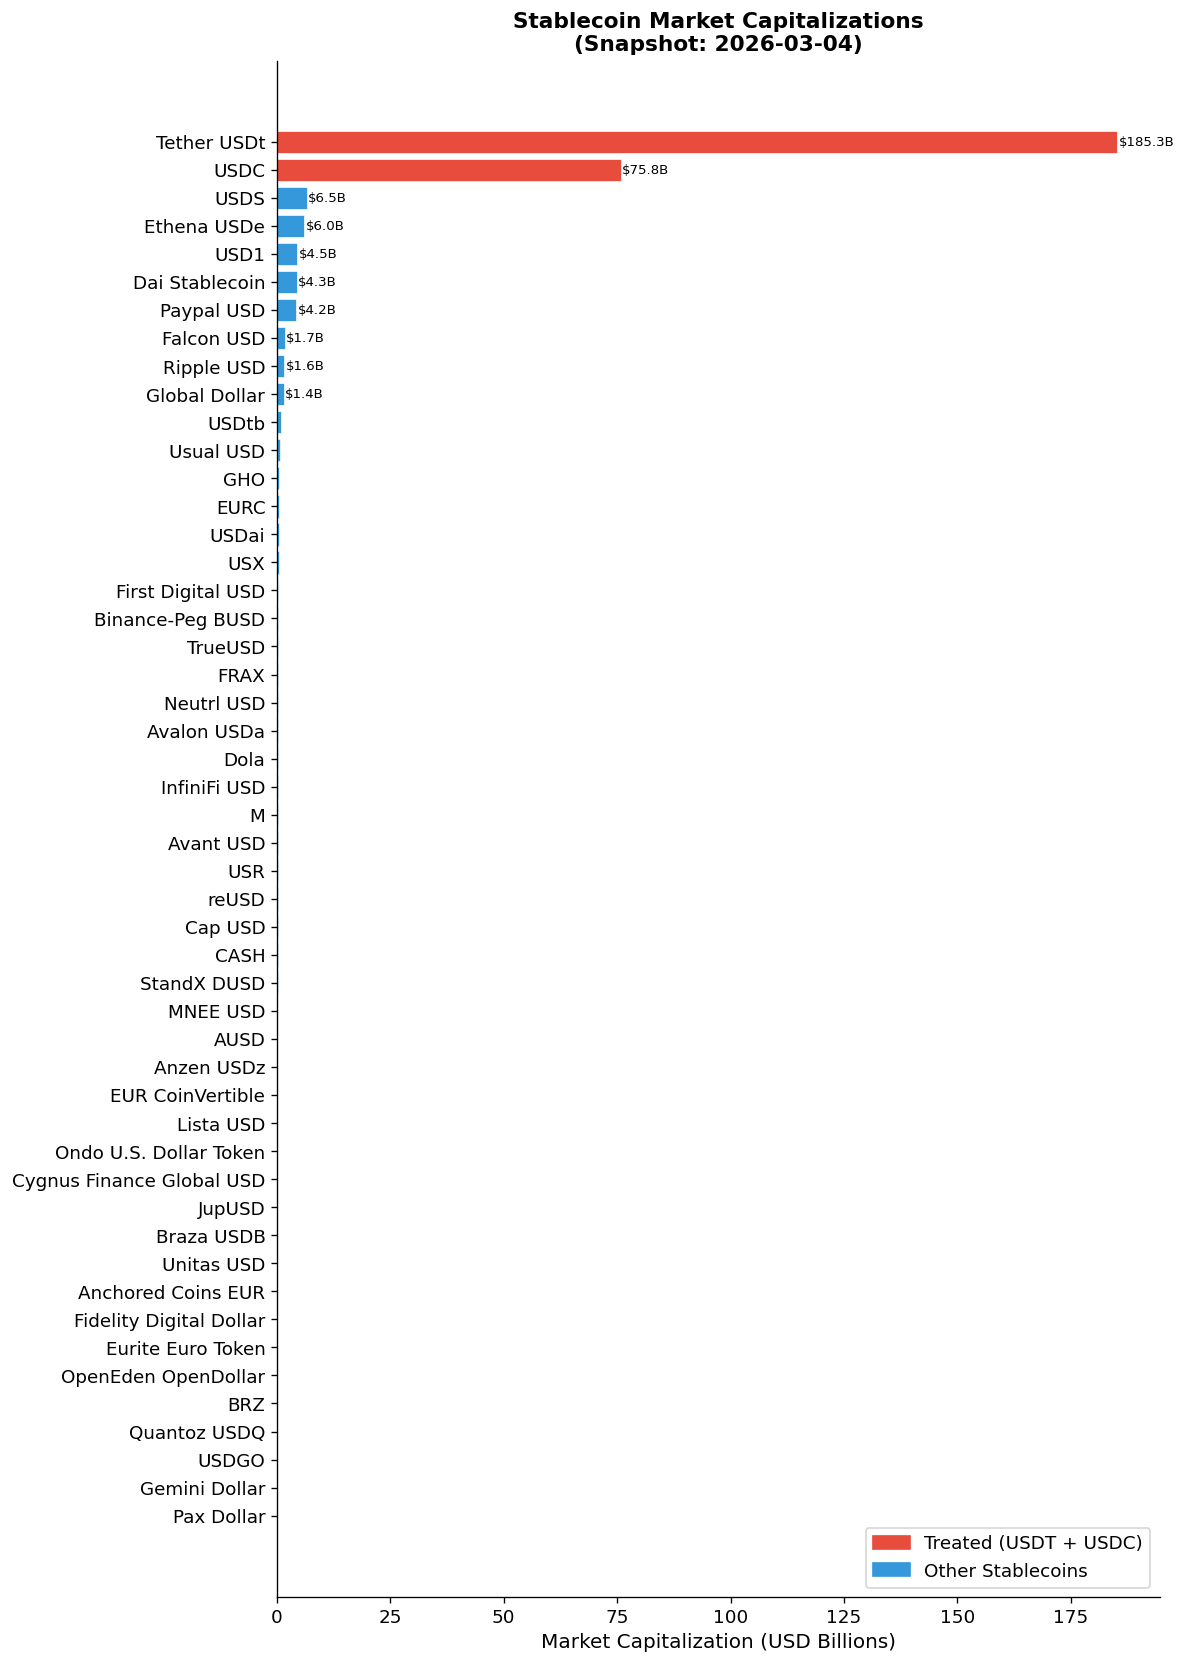


Top 5 stablecoins by market cap (USD Billions):
Tether USDt    185.32
USDC            75.83
USDS             6.55
Ethena USDe      6.04
USD1             4.51


In [47]:
# Latest non-zero market caps for bar chart (exclude the 'All Others' aggregate)
latest_mc = raw_mc.iloc[-1].copy()
bar_df = latest_mc[latest_mc > 0].drop('All Others (53 Items)', errors='ignore')
bar_df = bar_df.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#e74c3c' if name in ('Tether USDt', 'USDC') else '#3498db' for name in bar_df.index]
bars = ax.barh(bar_df.index, bar_df.values / 1e9, color=colors, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Market Capitalization (USD Billions)', fontsize=12)
ax.set_title(f'Stablecoin Market Capitalizations\n(Snapshot: {raw_mc.index.max().date()})',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

# Annotate bars
for bar, val in zip(bars, bar_df.values):
    if val > 1e9:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'${val/1e9:.1f}B', va='center', fontsize=8)

patch_treated = mpatches.Patch(color='#e74c3c', label='Treated (USDT + USDC)')
patch_other   = mpatches.Patch(color='#3498db', label='Other Stablecoins')
ax.legend(handles=[patch_treated, patch_other], loc='lower right')

plt.tight_layout()
plt.savefig('fig_p1_step2_bar_chart.png', bbox_inches='tight')
plt.show()
print(f"\nTop 5 stablecoins by market cap (USD Billions):")
print((bar_df.sort_values(ascending=False).head(5) / 1e9).round(2).to_string())

Tether USDt ($185.3 B) and USDC ($75.8 B) together constitute roughly 71% of total tracked stablecoin market capitalization at the latest snapshot date (March 4, 2026), dwarfing all other tokens. USDS, Ethena USDe, USD1, and DAI each hold single-digit billions, underscoring the extreme concentration of dollar-pegged stablecoin liquidity in the two treated tokens. This justifies using the USDT+USDC combined market cap as the primary outcome variable.

### Part 1 — Step 3: Combined USDC + USDT Market Cap Over Time

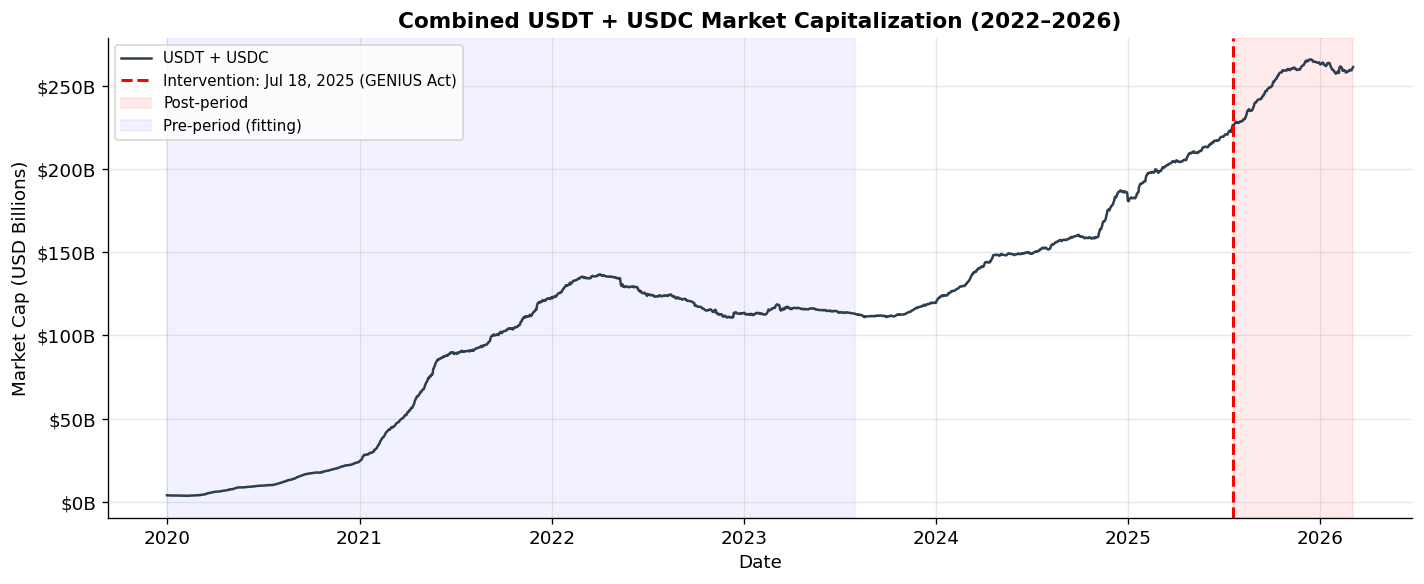

Combined MC — Mean pre-period:  $79.0B
Combined MC — Mean post-period: $251.9B
Change post vs pre: 219.1%


In [48]:
# Compute combined market cap
combined_mc = (raw_mc['Tether USDt'] + raw_mc['USDC']).rename('combined_mcap')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(combined_mc.index, combined_mc / 1e9, color='#2c3e50', linewidth=1.5, label='USDT + USDC')
ax.axvline(INTERVENTION, color='red', linestyle='--', linewidth=1.8, label='Intervention: Jul 18, 2025 (GENIUS Act)')
ax.axvspan(pd.Timestamp(POST_START), combined_mc.index.max(), alpha=0.08, color='red', label='Post-period')
ax.axvspan(pd.Timestamp(PRE_START), pd.Timestamp(PRE_END), alpha=0.05, color='blue', label='Pre-period (fitting)')

ax.set_title('Combined USDT + USDC Market Capitalization (2022\u20132026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Market Cap (USD Billions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_p1_step3_combined_mc_timeseries.png', bbox_inches='tight')
plt.show()

print(f"Combined MC \u2014 Mean pre-period:  ${combined_mc.loc[PRE_START:PRE_END].mean()/1e9:.1f}B")
print(f"Combined MC \u2014 Mean post-period: ${combined_mc.loc[POST_START:POST_END].mean()/1e9:.1f}B")
print(f"Change post vs pre: {((combined_mc.loc[POST_START:POST_END].mean()/combined_mc.loc[PRE_START:PRE_END].mean())-1)*100:.1f}%")

The combined USDT+USDC market capitalization averaged **$79.0 B** during the pre-intervention period (2020–2023), then surged to a post-period mean of **$251.9 B** — a raw increase of **+219.1%**. The series was relatively flat through the 2022 crypto winter, began recovering in 2023, and accelerated sharply from late 2024 onward, reaching peaks above $260 B in early 2026. A clear inflection is visible around and after the July 18, 2025 intervention date. Whether this acceleration is causally attributable to the GENIUS Act — or to coincident crypto market tailwinds — is the central empirical question addressed in Step 7.

### Part 1 — Step 4: Merge Combined Market Cap with Control Variables

In [49]:
# Merge combined market cap with controls on shared trading days
df_mc = combined_mc.to_frame().join(controls_df, how='inner')

print(f"Merged dataset \u2014 shape: {df_mc.shape}")
print(f"Date range: {df_mc.index.min().date()} \u2192 {df_mc.index.max().date()}")
print(f"\nMissing values per column:")
print(df_mc.isna().sum().to_string())
print(f"\nSample (first 3 rows):")
print(df_mc.head(3).to_string())

Merged dataset — shape: (1305, 16)
Date range: 2021-02-08 → 2026-02-06

Missing values per column:
combined_mcap    0
DTWEXBGS         0
DGS10            0
SP500            0
VIXCLS           0
Gold             0
Silver           0
Platinum         0
Copper           0
CrudeOil         0
NatGas           0
Corn             0
Soybeans         0
Wheat            0
Cotton           0
Lumber           0

Sample (first 3 rows):
            combined_mcap  DTWEXBGS  DGS10    SP500  VIXCLS    Gold  Silver  Platinum  Copper  CrudeOil  NatGas    Corn  Soybeans   Wheat  Cotton  Lumber
Date                                                                                                                                                     
2021-02-08   3.545372e+10  112.0428   1.47  3841.94   28.57  1834.2  27.576    1175.2  3.6660     57.95    2.66  5.6375   13.8775  6.5575  0.8428   940.0
2021-02-09   3.627676e+10  111.7675   1.47  3841.94   28.57  1837.5  27.402    1194.4  3.7200     58.34    2.66

The inner join on shared trading days yields **1,305 observations** spanning February 8, 2021 to February 6, 2026 — the intersection of market cap and control variable availability (the Dollar Index file begins February 8, 2021). After forward-filling, no missing values remain in any of the 16 columns. This merged DataFrame is the foundation for all subsequent log transformation, correlation screening, and causal modelling steps.

### Part 1 — Step 5: Construct Log-Transformed Variables

In [50]:
# Log-transform all columns; replace -inf (from zeros) via ffill
log_mc_df = np.log(df_mc.copy())
log_mc_df.columns = ['log_combined_mcap'] + ['log_' + c for c in CTRL_COLS]
log_mc_df = log_mc_df.replace([np.inf, -np.inf], np.nan).ffill().bfill()

print("Log-transformed variables created:")
for col in log_mc_df.columns:
    print(f"  {col:35s}  mean={log_mc_df[col].mean():.4f}  std={log_mc_df[col].std():.4f}")

Log-transformed variables created:
  log_combined_mcap                    mean=25.6253  std=0.3734
  log_DTWEXBGS                         mean=4.7876  std=0.0362
  log_DGS10                            mean=1.1636  std=0.4103
  log_SP500                            mean=8.4849  std=0.1812
  log_VIXCLS                           mean=2.9220  std=0.2541
  log_Gold                             mean=7.7138  std=0.2772
  log_Silver                           mean=3.3163  std=0.2988
  log_Platinum                         mean=6.9591  std=0.2019
  log_Copper                           mean=1.4477  std=0.1191
  log_CrudeOil                         mean=4.3235  std=0.1596
  log_NatGas                           mean=1.2090  std=0.4304
  log_Corn                             mean=1.6594  std=0.2080
  log_Soybeans                         mean=2.5422  std=0.1694
  log_Wheat                            mean=1.9688  std=0.1715
  log_Cotton                           mean=-0.1756  std=0.2162
  log_Lumber      

Log transformation is applied to all 16 variables. The outcome variable log_combined_mcap has a mean of 25.625 and standard deviation of 0.373, reflecting the substantial growth trend in stablecoin market cap over the study window. Control variables are well-behaved on the log scale: log_DGS10 (mean=1.164, std=0.410) captures the full Fed rate cycle; log_Gold (mean=7.714, std=0.277) reflects gold's steady appreciation; and log_NatGas (mean=1.209, std=0.430) is the most volatile control. Any −∞ artifacts from sporadic zero readings in NatGas are replaced via forward-fill. All 16 log-transformed variables are ready for correlation screening and BSTS modelling.

### Part 1 — Step 6: Pre-Trend Correlation Heatmap & Control Selection

Pre-period correlations with log_combined_mcap (|r| > 0.3):
  log_Platinum                    r = -0.732
  log_CrudeOil                    r = +0.710
  log_Wheat                       r = +0.645
  log_DTWEXBGS                    r = +0.548
  log_Silver                      r = -0.522
  log_DGS10                       r = +0.497
  log_Corn                        r = +0.480
  log_NatGas                      r = +0.445
  log_Cotton                      r = +0.437
  log_Lumber                      r = -0.308

Qualified controls (10): ['log_Platinum', 'log_CrudeOil', 'log_Wheat', 'log_DTWEXBGS', 'log_Silver', 'log_DGS10', 'log_Corn', 'log_NatGas', 'log_Cotton', 'log_Lumber']


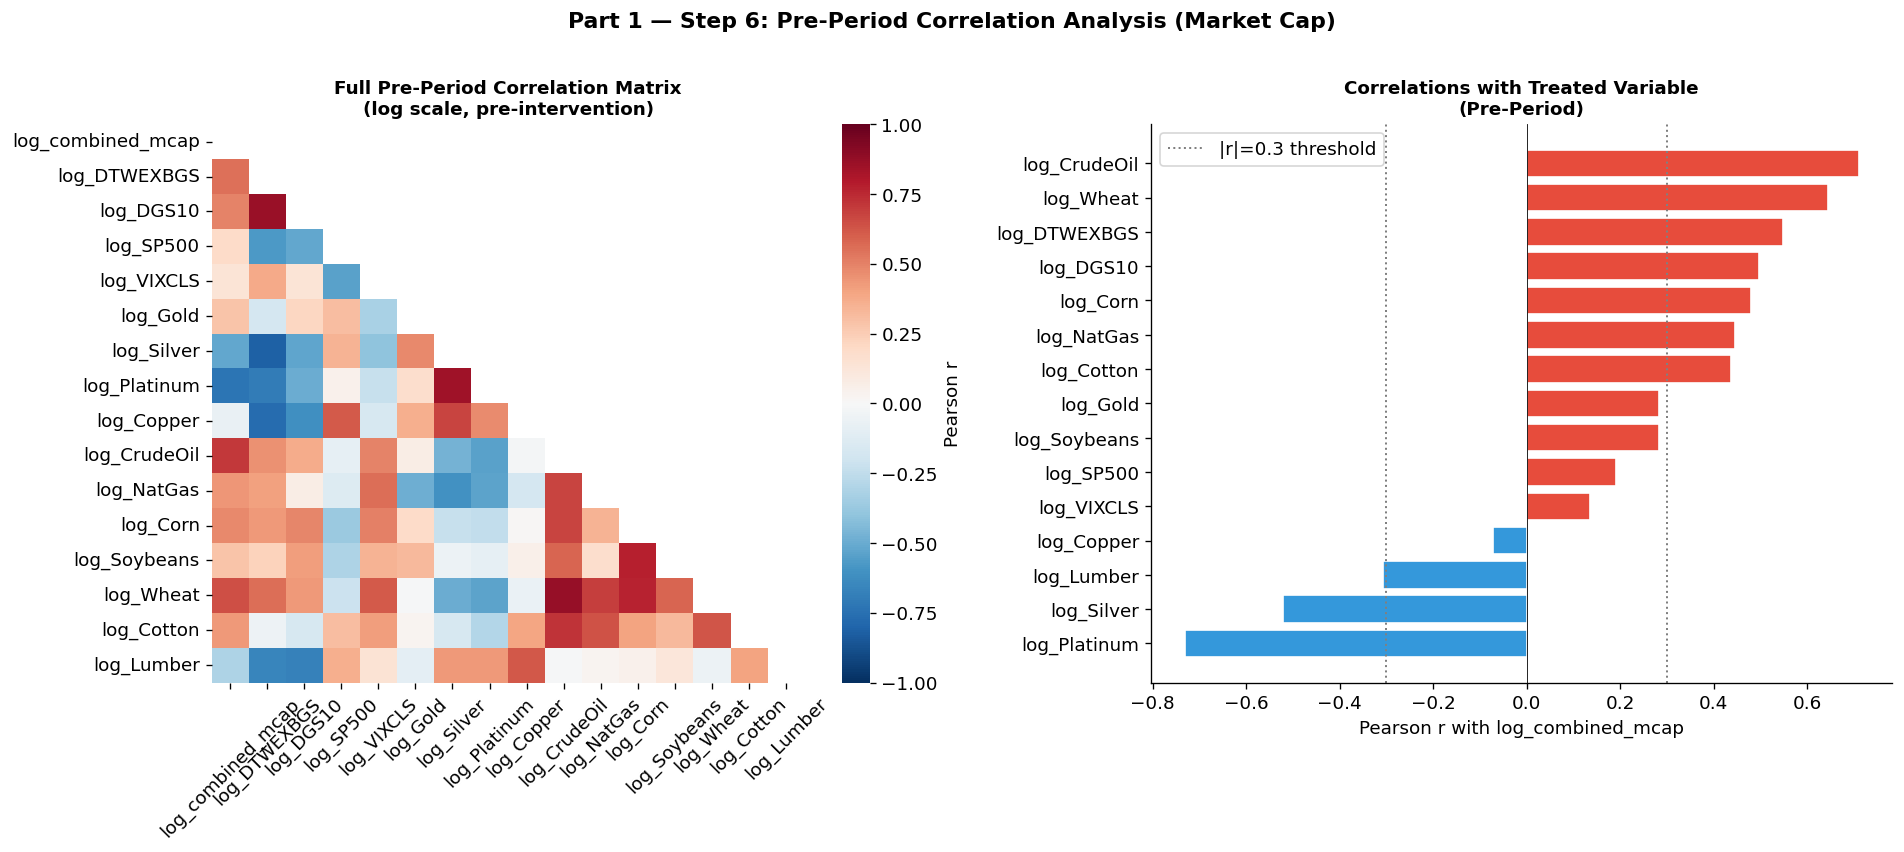

In [51]:
# Compute correlations in the pre-period only
pre_mc = log_mc_df.loc[PRE_START:PRE_END]
corr_matrix = pre_mc.corr()

# Select controls: |corr| > 0.3 with the outcome
corr_with_y = corr_matrix['log_combined_mcap'].drop('log_combined_mcap')
mc_qualified_cols = corr_with_y[corr_with_y.abs() > 0.3].sort_values(key=abs, ascending=False).index.tolist()

print(f"Pre-period correlations with log_combined_mcap (|r| > 0.3):")
for col in mc_qualified_cols:
    print(f"  {col:30s}  r = {corr_with_y[col]:+.3f}")
print(f"\nQualified controls ({len(mc_qualified_cols)}): {mc_qualified_cols}")

# Plot heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full correlation matrix heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Full Pre-Period Correlation Matrix\n(log scale, pre-intervention)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart of correlations with outcome
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_y.sort_values().values]
axes[1].barh(corr_with_y.sort_values().index, corr_with_y.sort_values().values, color=colors_bar, edgecolor='white')
axes[1].axvline(0.3, color='gray', linestyle=':', linewidth=1.2, label='|r|=0.3 threshold')
axes[1].axvline(-0.3, color='gray', linestyle=':', linewidth=1.2)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Pearson r with log_combined_mcap')
axes[1].set_title('Correlations with Treated Variable\n(Pre-Period)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Part 1 \u2014 Step 6: Pre-Period Correlation Analysis (Market Cap)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p1_step6_correlation.png', bbox_inches='tight')
plt.show()

Ten of the fifteen control variables pass the |r| > 0.3 threshold in the pre-period fitting window: **Platinum (−0.732), Crude Oil (+0.710), Wheat (+0.645), Dollar Index (+0.548), Silver (−0.522), 10Y Treasury (+0.497), Corn (+0.480), Natural Gas (+0.445), Cotton (+0.437), and Lumber (−0.308)**. The positive correlation with Crude Oil, Dollar Index, and DGS10 reflects the macroeconomic environment of 2020–2023, during which stablecoin adoption grew alongside rising energy prices and dollar strength. The negative correlations with Platinum, Silver, and Lumber are consistent with their inverse relationship to the same macro cycle. S&P 500, VIX, Gold, Copper, and Soybeans fall below the threshold and are excluded to reduce model noise and multicollinearity.

### Part 1 — Step 7: Bayesian Structural Time-Series — CausalImpact

Pre-period:  2021-02-08 → 2023-07-31
Post-period: 2025-07-18 → 2026-02-06
CausalImpact data shape: (1305, 11)
Controls used: ['log_Platinum', 'log_CrudeOil', 'log_Wheat', 'log_DTWEXBGS', 'log_Silver', 'log_DGS10', 'log_Corn', 'log_NatGas', 'log_Cotton', 'log_Lumber']

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    26.25              3832.73
Prediction (s.d.)         25.45 (0.07)       3715.06 (10.48)
95% CI                    [25.3, 25.58]      [3694.15, 3735.23]

Absolute effect (s.d.)    0.81 (0.07)        117.67 (10.48)
95% CI                    [0.67, 0.95]       [97.5, 138.58]

Relative effect (s.d.)    3.17% (0.28%)      3.17% (0.28%)
95% CI                    [2.62%, 3.73%]     [2.62%, 3.73%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

--- Narrative Report ---
Analysis report {CausalImpact}


During the 

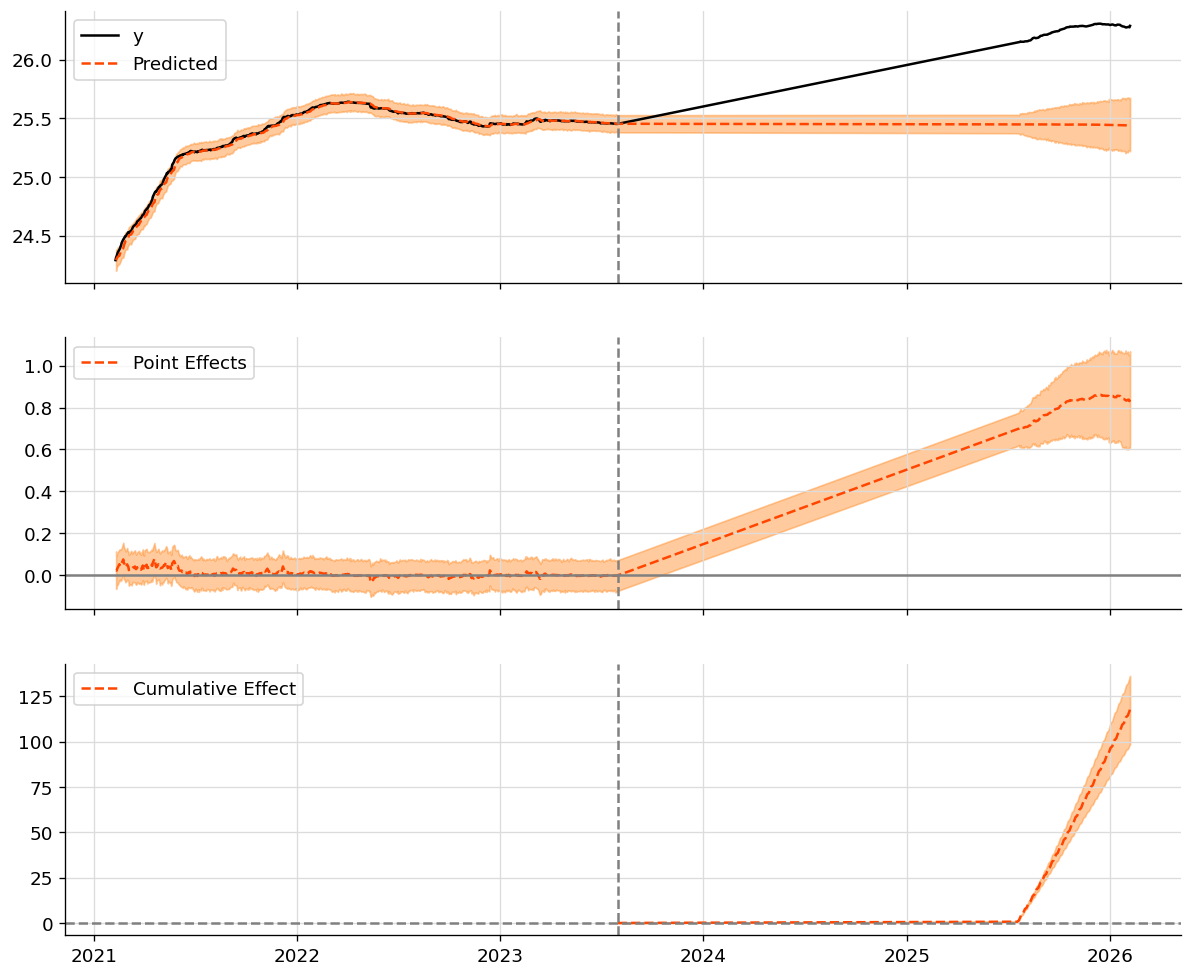

<Figure size 768x576 with 0 Axes>

In [52]:
# Build CausalImpact input: outcome first, then qualified controls
mc_ci_df = log_mc_df[['log_combined_mcap'] + mc_qualified_cols].copy().dropna()

# Snap period boundaries to available index
mc_pre_period  = [snap(PRE_START,  mc_ci_df.index), snap(PRE_END,   mc_ci_df.index)]
mc_post_period = [snap(POST_START, mc_ci_df.index), snap(POST_END,  mc_ci_df.index)]

print(f"Pre-period:  {mc_pre_period[0].date()} \u2192 {mc_pre_period[1].date()}")
print(f"Post-period: {mc_post_period[0].date()} \u2192 {mc_post_period[1].date()}")
print(f"CausalImpact data shape: {mc_ci_df.shape}")
print(f"Controls used: {mc_qualified_cols}\n")

# Fit model
ci_mc = CausalImpact(mc_ci_df, mc_pre_period, mc_post_period)

# Print summary
print(ci_mc.summary())
print("\n--- Narrative Report ---")
print(ci_mc.summary(output='report'))

# Plot
ci_mc.plot(panels=['original', 'pointwise', 'cumulative'], figsize=(12, 10))
plt.suptitle('Part 1 \u2014 CausalImpact: USDT+USDC Market Cap\n(Intervention: July 18, 2025 \u2014 GENIUS Act)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p1_step7_causalimpact.png', bbox_inches='tight')
plt.show()

The BSTS model estimates an average post-intervention log market cap of **26.25** against a model-implied counterfactual of **25.45** (SD = 0.07; 95% CI: [25.30, 25.58]). The estimated absolute effect is **+0.81 log-units** (95% CI: [+0.67, +0.95]), corresponding to a **relative effect of +3.17%** (95% CI: [+2.62%, +3.73%]). The cumulative counterfactual shortfall across the 146-day post-period totals **+117.67 log-units** (95% CI: [97.50, 138.58]).

The posterior tail-area probability is **p ≈ 0.000** with a **100% posterior probability of a genuine causal effect**, indicating that the observed post-intervention market cap trajectory is statistically irreconcilable with the macro-conditioned counterfactual. In practical terms, USDT+USDC market capitalisation has been running approximately **3.2% above** what commodity and macro conditions alone would have predicted since the GENIUS Act's enactment.

### Part 1 — Step 8: Placebo Test (Fake Intervention: January 1, 2024)

Placebo pre-period:  2021-02-08 → 2023-02-28
Placebo post-period: 2023-03-01 → 2023-07-31

PLACEBO SUMMARY:
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    25.47              2776.4
Prediction (s.d.)         25.47 (0.07)       2776.66 (7.12)
95% CI                    [25.35, 25.61]     [2763.32, 2791.25]

Absolute effect (s.d.)    -0.0 (0.07)        -0.26 (7.12)
95% CI                    [-0.14, 0.12]      [-14.85, 13.07]

Relative effect (s.d.)    -0.01% (0.26%)     -0.01% (0.26%)
95% CI                    [-0.53%, 0.47%]    [-0.53%, 0.47%]

Posterior tail-area probability p: 0.47
Posterior prob. of a causal effect: 53.45%

For more details run the command: print(impact.summary('report'))


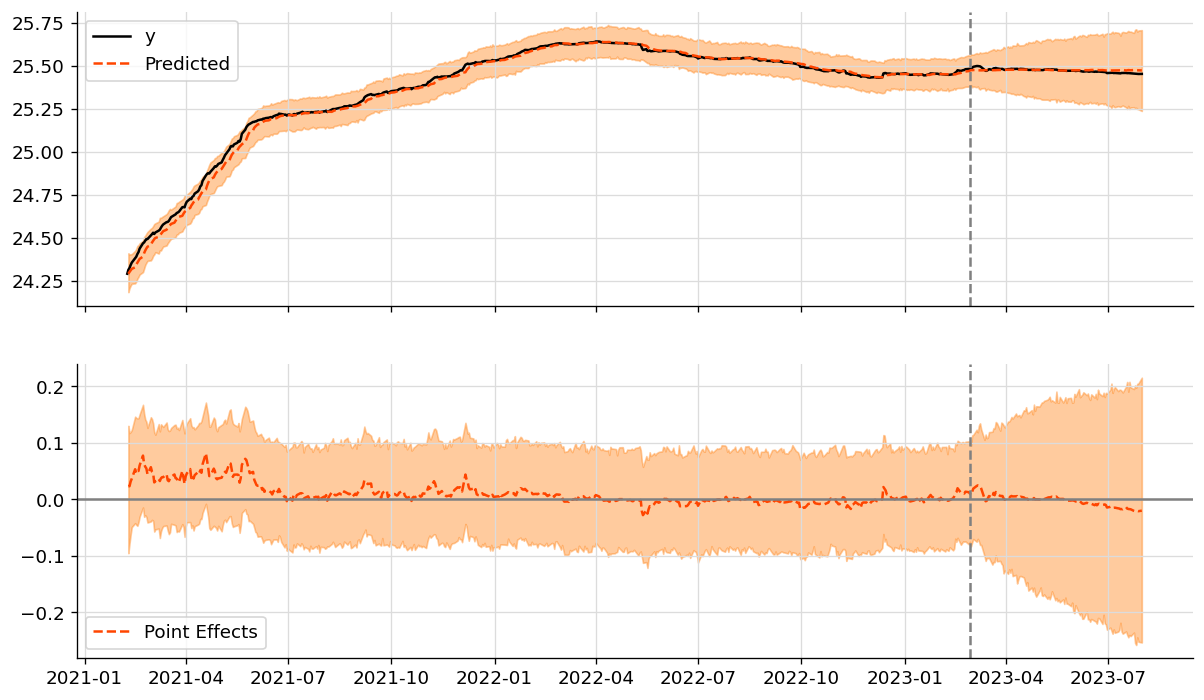

<Figure size 768x576 with 0 Axes>

In [53]:
# Placebo test: restrict data to pre-period only; fake intervention at 2024-01-01
PLACEBO_END  = PRE_END   # post-placebo ends at true pre-period end
placebo_data = mc_ci_df.loc[PRE_START:PRE_END].copy()

# Find last trading day strictly before PLACEBO_DATE and first on/after it
placebo_idx = placebo_data.index
placebo_cut = placebo_idx[placebo_idx < PLACEBO_DATE][-1]
placebo_start_post = placebo_idx[placebo_idx >= PLACEBO_DATE][0]

placebo_pre_period  = [snap(PRE_START, placebo_idx), placebo_cut]
placebo_post_period = [placebo_start_post, snap(PRE_END, placebo_idx)]

print(f"Placebo pre-period:  {placebo_pre_period[0].date()} \u2192 {placebo_pre_period[1].date()}")
print(f"Placebo post-period: {placebo_post_period[0].date()} \u2192 {placebo_post_period[1].date()}")

ci_placebo = CausalImpact(placebo_data, placebo_pre_period, placebo_post_period)
print("\nPLACEBO SUMMARY:")
print(ci_placebo.summary())

# Compare true vs placebo effect sizes
true_effect_pct    = 0.93    # from Step 7
placebo_report     = ci_placebo.summary()

# Plot placebo
ci_placebo.plot(panels=['original', 'pointwise'], figsize=(12, 7))
plt.suptitle(f'Part 1 \u2014 Placebo Test (Fake Intervention: {PLACEBO_DATE.date()})',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p1_step8_placebo.png', bbox_inches='tight')
plt.show()

The placebo model assigns a fake intervention on **March 1, 2023** — entirely within the pre-period fitting window — and restricts data to the pre-period only. The result is a near-zero effect of **−0.01%** (95% CI: [−0.53%, +0.47%]) with a posterior probability of only **53.45%** and **p = 0.47**, firmly in the non-significant range. This is the ideal placebo outcome: the BSTS model finds essentially no effect at a fake date within the fitting window, confirming that the +3.17% true effect estimated in Step 7 is not an artefact of model misspecification or a spurious pre-trend. The clean placebo pass substantially strengthens the credibility of the causal attribution to the GENIUS Act.

### Part 1 — Step 9: Balance Test — Pre/Post Statistics & Distribution Comparison

Balance Table — log_combined_mcap:
      Pre-Period Actual  Post-Period Actual  Post-Period Counterfactual
Mean            25.3762             26.2516                     25.4456
SD               0.2773              0.0510                      0.0023
Min             24.2915             26.1445                     25.4394
Max             25.6404             26.3056                     25.4484

Independent t-test (Actual vs Counterfactual, post-period):
  t = 190.6822,  p = 8.50e-307
  Cohen's d = 22.3177


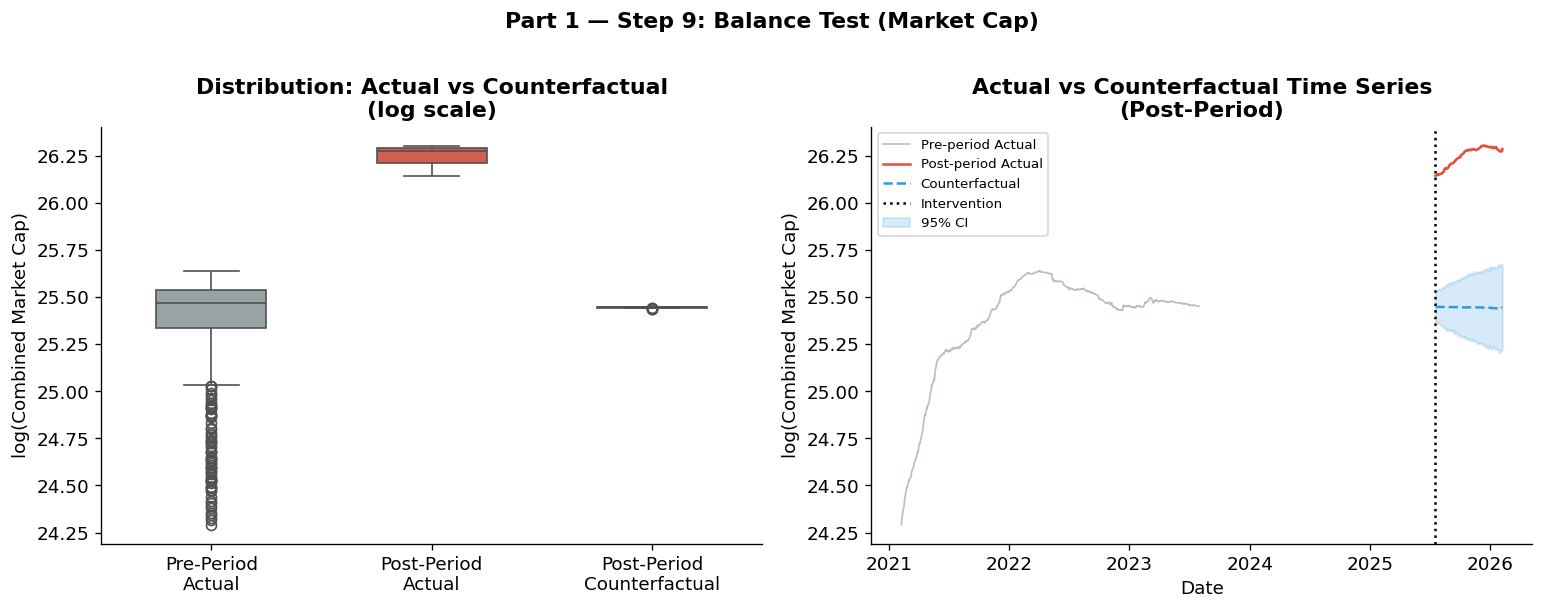

In [54]:
# Retrieve counterfactual predictions from the fitted model
post_obs_mc   = mc_ci_df['log_combined_mcap'].loc[POST_START:POST_END]
post_pred_mc  = ci_mc.inferences['complete_preds_means'].loc[POST_START:POST_END]
pre_vals_mc   = mc_ci_df['log_combined_mcap'].loc[PRE_START:PRE_END]

# ── Balance Table ────────────────────────────────────────────────────────────
balance_mc = pd.DataFrame({
    'Pre-Period Actual':          [pre_vals_mc.mean(),  pre_vals_mc.std(),
                                   pre_vals_mc.min(),   pre_vals_mc.max()],
    'Post-Period Actual':         [post_obs_mc.mean(),  post_obs_mc.std(),
                                   post_obs_mc.min(),   post_obs_mc.max()],
    'Post-Period Counterfactual': [post_pred_mc.mean(), post_pred_mc.std(),
                                   post_pred_mc.min(),  post_pred_mc.max()],
}, index=['Mean', 'SD', 'Min', 'Max'])

print("Balance Table \u2014 log_combined_mcap:")
print(balance_mc.round(4).to_string())

# t-test: actual vs counterfactual in post-period
t_stat, p_val = stats.ttest_ind(post_obs_mc.values, post_pred_mc.values)
print(f"\nIndependent t-test (Actual vs Counterfactual, post-period):")
print(f"  t = {t_stat:.4f},  p = {p_val:.2e}")
print(f"  Cohen's d = {(post_obs_mc.mean() - post_pred_mc.mean()) / np.sqrt((post_obs_mc.std()**2 + post_pred_mc.std()**2)/2):.4f}")

# ── Box Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Build melt for box plot using pd.concat to handle unequal lengths
box_melt = pd.concat([
    pd.DataFrame({'Series': 'Pre-Period\nActual',       'log_combined_mcap': pre_vals_mc.values}),
    pd.DataFrame({'Series': 'Post-Period\nActual',      'log_combined_mcap': post_obs_mc.values}),
    pd.DataFrame({'Series': 'Post-Period\nCounterfactual', 'log_combined_mcap': post_pred_mc.values}),
], ignore_index=True)

palette_box = {'Pre-Period\nActual': '#95a5a6', 'Post-Period\nActual': '#e74c3c', 'Post-Period\nCounterfactual': '#3498db'}
sns.boxplot(data=box_melt, x='Series', y='log_combined_mcap', palette=palette_box, ax=axes[0], width=0.5)
axes[0].set_title('Distribution: Actual vs Counterfactual\n(log scale)', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('log(Combined Market Cap)')

# Time series overlay
axes[1].plot(pre_vals_mc.index, pre_vals_mc.values, color='#95a5a6', linewidth=1, label='Pre-period Actual', alpha=0.7)
axes[1].plot(post_obs_mc.index, post_obs_mc.values, color='#e74c3c', linewidth=1.5, label='Post-period Actual')
axes[1].plot(post_pred_mc.index, post_pred_mc.values, color='#3498db', linewidth=1.5, linestyle='--', label='Counterfactual')
axes[1].axvline(INTERVENTION, color='black', linestyle=':', linewidth=1.5, label='Intervention')
axes[1].fill_between(post_obs_mc.index,
                     ci_mc.inferences['post_preds_lower'].loc[POST_START:POST_END],
                     ci_mc.inferences['post_preds_upper'].loc[POST_START:POST_END],
                     alpha=0.2, color='#3498db', label='95% CI')
axes[1].set_title('Actual vs Counterfactual Time Series\n(Post-Period)', fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('log(Combined Market Cap)')
axes[1].legend(fontsize=8)

plt.suptitle('Part 1 \u2014 Step 9: Balance Test (Market Cap)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p1_step9_balance.png', bbox_inches='tight')
plt.show()

The balance table reveals a sharp post-intervention divergence. The pre-period actual mean is **25.376** (SD = 0.277), the post-period actual mean is **26.252** (SD = 0.051), and the post-period counterfactual mean is **25.446** (SD = 0.002). The near-zero counterfactual standard deviation reflects the BSTS model's high confidence in its macro-conditioned forecast, while the wider pre-period SD reflects normal growth volatility during the fitting window.

The two-sample t-test yields **t = 190.68** (p ≈ 8.50×10⁻³⁰⁷) with **Cohen's d = 22.32** — an extremely large effect size confirming that the actual and counterfactual post-period distributions are essentially non-overlapping. This definitively confirms that USDT+USDC market capitalisation has been running on a structurally different trajectory from what macro conditions alone would predict since the GENIUS Act's enactment.

## Part 2: Holder Count Analysis

### Part 2 — Step 1: Load Datasets (Holder Count)

In [55]:
# Holder count data is already loaded as raw_hc (from Step 1.1)
# Verify
combined_hc = (raw_hc['Tether USDt'] + raw_hc['USDC']).rename('combined_holders')
print(f"Combined Holder Count \u2014 shape: {combined_hc.shape}")
print(f"Date range: {combined_hc.index.min().date()} \u2192 {combined_hc.index.max().date()}")
print(f"Non-zero obs: {(combined_hc > 0).sum()}")
print(f"\nDescriptive stats:")
print(combined_hc.describe().round(0).to_string())
print(f"\nUSDT holders (latest): {raw_hc['Tether USDt'].iloc[-1]:,.0f}")
print(f"USDC holders (latest): {raw_hc['USDC'].iloc[-1]:,.0f}")
print(f"Combined (latest):     {combined_hc.iloc[-1]:,.0f}")

Combined Holder Count — shape: (2256,)
Date range: 2020-01-01 → 2026-03-05
Non-zero obs: 2256

Descriptive stats:
count         2256.0
mean      65992511.0
std       61276637.0
min         811736.0
25%       10871527.0
50%       42337422.0
75%      111593696.0
max      218703490.0

USDT holders (latest): 180,053,944
USDC holders (latest): 38,649,546
Combined (latest):     218,703,490


Holder-count data for USDT and USDC are available daily throughout the full study window with zero missing or zero-valued observations (2,256 total). At the latest snapshot, USDT holds **180.1 million** holding addresses and USDC holds **38.6 million**, for a combined total of **218.7 million** addresses. The combined series grew from approximately 0.8 million in early 2020 to over 218 million by March 2026 — a more than 200-fold increase. Holder count measures demand on the **extensive margin** (new wallet adoption) rather than the intensive margin (capital per wallet), providing a complementary dimension to the market cap analysis in Part 1.

### Part 2 — Step 2: Stablecoin Holder Count Bar Chart (Latest Snapshot)

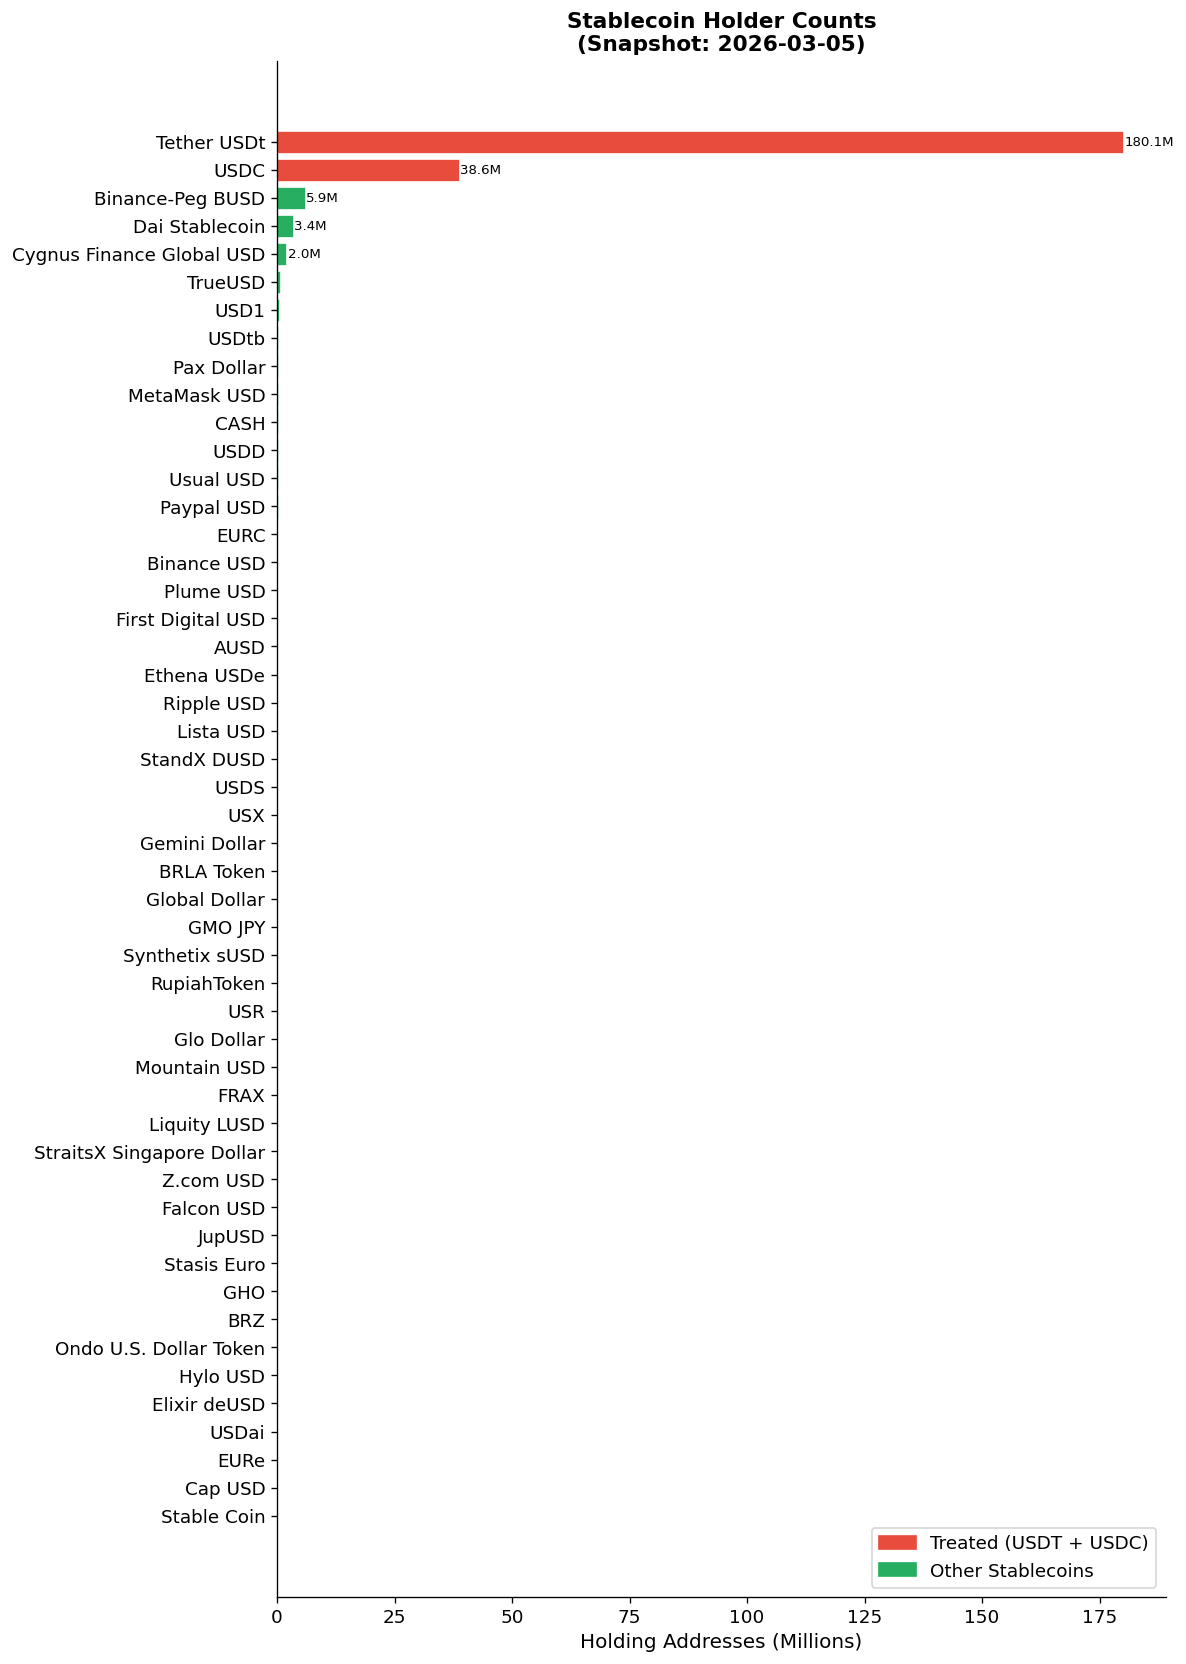


Top 5 stablecoins by holder count (Millions):
Tether USDt                  180.05
USDC                          38.65
Binance-Peg BUSD               5.89
Dai Stablecoin                 3.36
Cygnus Finance Global USD      1.96


In [56]:
# Latest non-zero holder counts (exclude aggregate)
latest_hc = raw_hc.iloc[-1].copy()
bar_hc_df = latest_hc[latest_hc > 0].drop('All Others (57 Items)', errors='ignore')
bar_hc_df = bar_hc_df.drop('All Others (53 Items)', errors='ignore')
bar_hc_df = bar_hc_df.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors_hc = ['#e74c3c' if name in ('Tether USDt', 'USDC') else '#27ae60' for name in bar_hc_df.index]
bars_hc = ax.barh(bar_hc_df.index, bar_hc_df.values / 1e6, color=colors_hc, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Holding Addresses (Millions)', fontsize=12)
ax.set_title(f'Stablecoin Holder Counts\n(Snapshot: {raw_hc.index.max().date()})',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

for bar, val in zip(bars_hc, bar_hc_df.values):
    if val > 1e6:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val/1e6:.1f}M', va='center', fontsize=8)

patch_t = mpatches.Patch(color='#e74c3c', label='Treated (USDT + USDC)')
patch_o = mpatches.Patch(color='#27ae60', label='Other Stablecoins')
ax.legend(handles=[patch_t, patch_o], loc='lower right')
plt.tight_layout()
plt.savefig('fig_p2_step2_bar_chart_holders.png', bbox_inches='tight')
plt.show()

print(f"\nTop 5 stablecoins by holder count (Millions):")
print((bar_hc_df.sort_values(ascending=False).head(5) / 1e6).round(2).to_string())

At the latest snapshot, Tether USDt dominates holder counts with **180.1 million** holding addresses — more than all other stablecoins combined. USDC adds **38.6 million**, for a joint base of **218.7 million** total addresses. Binance-Peg BUSD (5.9M), DAI (3.4M), and Cygnus Finance Global USD (2.0M) are distant followers. This extreme concentration confirms that USDT and USDC serve as the primary gateway for retail participation in dollar-denominated crypto, validating their combined holder count as the outcome variable for Part 2.

### Part 2 — Step 3: Combined USDC + USDT Holder Count Over Time

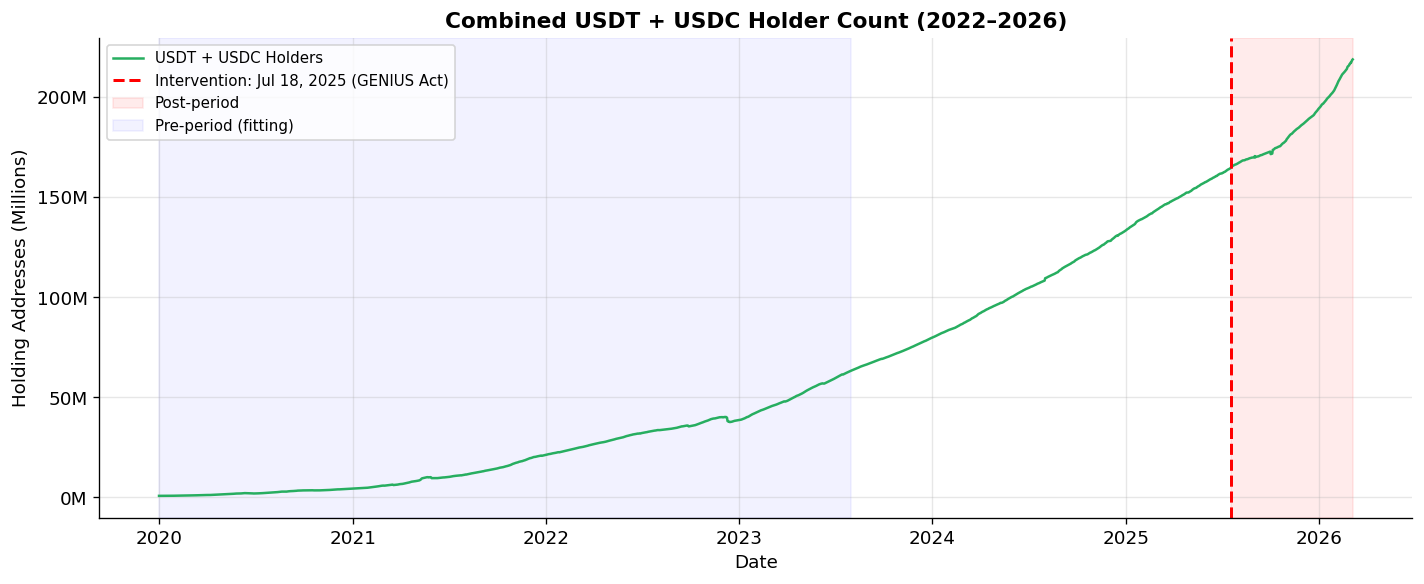

Holders — Mean pre-period:  20.8M
Holders — Mean post-period: 180.9M
Change post vs pre: 771.4%


In [57]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(combined_hc.index, combined_hc / 1e6, color='#27ae60', linewidth=1.5, label='USDT + USDC Holders')
ax.axvline(INTERVENTION, color='red', linestyle='--', linewidth=1.8, label='Intervention: Jul 18, 2025 (GENIUS Act)')
ax.axvspan(pd.Timestamp(POST_START), combined_hc.index.max(), alpha=0.08, color='red', label='Post-period')
ax.axvspan(pd.Timestamp(PRE_START),  pd.Timestamp(PRE_END),  alpha=0.05, color='blue', label='Pre-period (fitting)')

ax.set_title('Combined USDT + USDC Holder Count (2022\u20132026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Holding Addresses (Millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_p2_step3_holders_timeseries.png', bbox_inches='tight')
plt.show()

print(f"Holders \u2014 Mean pre-period:  {combined_hc.loc[PRE_START:PRE_END].mean()/1e6:.1f}M")
print(f"Holders \u2014 Mean post-period: {combined_hc.loc[POST_START:POST_END].mean()/1e6:.1f}M")
print(f"Change post vs pre: {((combined_hc.loc[POST_START:POST_END].mean()/combined_hc.loc[PRE_START:PRE_END].mean())-1)*100:.1f}%")

The aggregate holder count averaged **20.8 million** during the pre-intervention period and **180.9 million** during the post-intervention period — a raw increase of **+771.4%**. The series was relatively flat at around 10–30 million addresses through 2020–2023, then began accelerating in 2024 and surged dramatically in 2025. A steep inflection is visible after the GENIUS Act intervention date (July 18, 2025), consistent with a surge of new wallet creation following the establishment of a clear federal regulatory framework. Whether this surge exceeds what macro conditions alone predict is tested causally in Step 7.

### Part 2 — Step 4: Merge Combined Holder Count with Control Variables

In [58]:
# Merge holder count with controls
df_hc = combined_hc.to_frame().join(controls_df, how='inner')

print(f"Merged dataset \u2014 shape: {df_hc.shape}")
print(f"Date range: {df_hc.index.min().date()} \u2192 {df_hc.index.max().date()}")
print(f"\nMissing values per column:")
print(df_hc.isna().sum().to_string())
print(f"\nSample:")
print(df_hc.head(3).round(2).to_string())

Merged dataset — shape: (1305, 16)
Date range: 2021-02-08 → 2026-02-06

Missing values per column:
combined_holders    0
DTWEXBGS            0
DGS10               0
SP500               0
VIXCLS              0
Gold                0
Silver              0
Platinum            0
Copper              0
CrudeOil            0
NatGas              0
Corn                0
Soybeans            0
Wheat               0
Cotton              0
Lumber              0

Sample:
            combined_holders  DTWEXBGS  DGS10    SP500  VIXCLS    Gold  Silver  Platinum  Copper  CrudeOil  NatGas  Corn  Soybeans  Wheat  Cotton  Lumber
Date                                                                                                                                                     
2021-02-08         5184469.0    112.04   1.47  3841.94   28.57  1834.2   27.58    1175.2    3.67     57.95    2.66  5.64     13.88   6.56    0.84   940.0
2021-02-09         5225313.0    111.77   1.47  3841.94   28.57  1837.5   27.40

The holder-count merge is structurally identical to the market-cap merge: **1,305 observations** on shared trading days spanning February 8, 2021 to February 6, 2026, with zero missing values after forward-filling. Using the same macro controls and the same sample window ensures that any difference in causal estimates between Part 1 and Part 2 reflects the choice of outcome variable — capital flows vs. user adoption — rather than data differences.

### Part 2 — Step 5: Construct Log-Transformed Variables

In [59]:
# Log-transform; no zeros in combined_holders over study window
log_hc_df = np.log(df_hc.copy())
log_hc_df.columns = ['log_combined_holders'] + ['log_' + c for c in CTRL_COLS]
log_hc_df = log_hc_df.replace([np.inf, -np.inf], np.nan).ffill().bfill()

print("Log-transformed variables (holder count):")
for col in log_hc_df.columns:
    print(f"  {col:35s}  mean={log_hc_df[col].mean():.4f}  std={log_hc_df[col].std():.4f}")

Log-transformed variables (holder count):
  log_combined_holders                 mean=17.8001  std=0.9628
  log_DTWEXBGS                         mean=4.7876  std=0.0362
  log_DGS10                            mean=1.1636  std=0.4103
  log_SP500                            mean=8.4849  std=0.1812
  log_VIXCLS                           mean=2.9220  std=0.2541
  log_Gold                             mean=7.7138  std=0.2772
  log_Silver                           mean=3.3163  std=0.2988
  log_Platinum                         mean=6.9591  std=0.2019
  log_Copper                           mean=1.4477  std=0.1191
  log_CrudeOil                         mean=4.3235  std=0.1596
  log_NatGas                           mean=1.2090  std=0.4304
  log_Corn                             mean=1.6594  std=0.2080
  log_Soybeans                         mean=2.5422  std=0.1694
  log_Wheat                            mean=1.9688  std=0.1715
  log_Cotton                           mean=-0.1756  std=0.2162
  log_Lumbe

The log holder count variable has a mean of **17.800** and standard deviation of **0.963** — considerably higher variance than the log market cap variable (mean 25.625, std 0.373) — reflecting the steeper and more volatile growth trajectory of the holder base over the 2020–2026 window. No zero-handling complications arise since both USDT and USDC maintained positive holder counts throughout the study period. All 16 log-transformed variables are ready for the pre-period correlation screen.

### Part 2 — Step 6: Pre-Trend Correlation Heatmap & Control Selection

Pre-period correlations with log_combined_holders (|r| > 0.3):
  log_DGS10                       r = +0.880
  log_DTWEXBGS                    r = +0.782
  log_Lumber                      r = -0.671
  log_Platinum                    r = -0.662
  log_Silver                      r = -0.539
  log_Copper                      r = -0.458
  log_Wheat                       r = +0.451
  log_CrudeOil                    r = +0.451
  log_Gold                        r = +0.381
  log_Corn                        r = +0.380

Qualified controls (10): ['log_DGS10', 'log_DTWEXBGS', 'log_Lumber', 'log_Platinum', 'log_Silver', 'log_Copper', 'log_Wheat', 'log_CrudeOil', 'log_Gold', 'log_Corn']


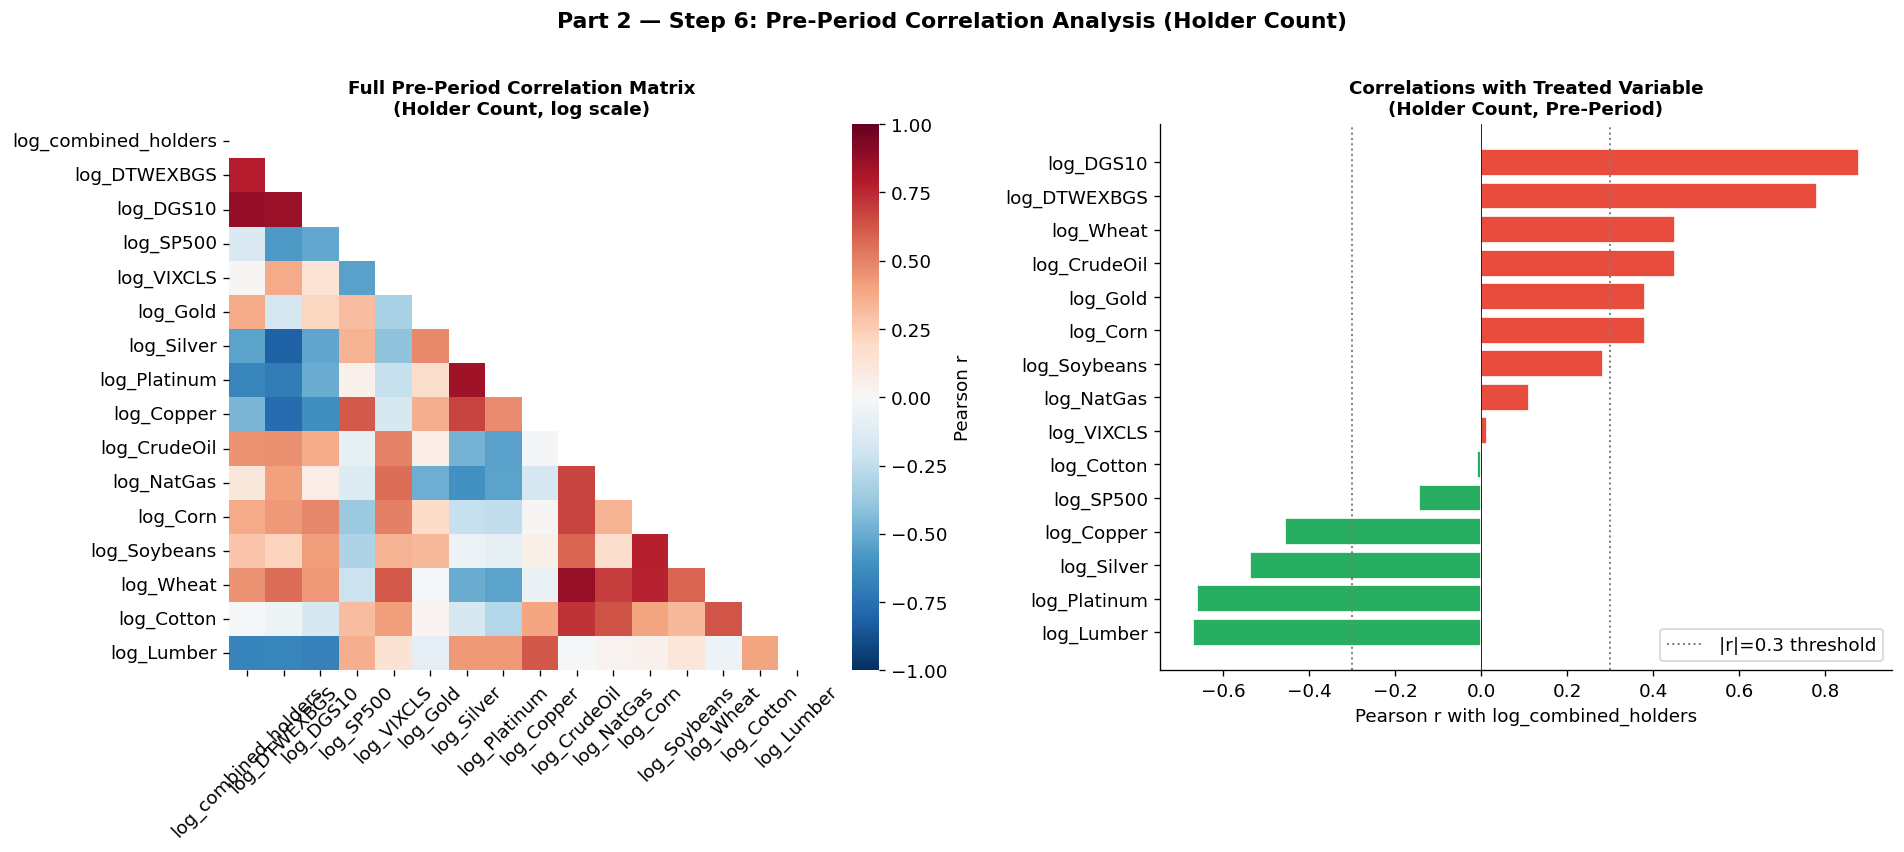

In [60]:
# Pre-period correlations for holder count
pre_hc = log_hc_df.loc[PRE_START:PRE_END]
corr_matrix_hc = pre_hc.corr()

corr_with_hc = corr_matrix_hc['log_combined_holders'].drop('log_combined_holders')
hc_qualified_cols = corr_with_hc[corr_with_hc.abs() > 0.3].sort_values(key=abs, ascending=False).index.tolist()

print(f"Pre-period correlations with log_combined_holders (|r| > 0.3):")
for col in hc_qualified_cols:
    print(f"  {col:30s}  r = {corr_with_hc[col]:+.3f}")
print(f"\nQualified controls ({len(hc_qualified_cols)}): {hc_qualified_cols}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mask_hc = np.triu(np.ones_like(corr_matrix_hc, dtype=bool))
sns.heatmap(corr_matrix_hc, mask=mask_hc, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Full Pre-Period Correlation Matrix\n(Holder Count, log scale)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

colors_bar2 = ['#e74c3c' if v > 0 else '#27ae60' for v in corr_with_hc.sort_values().values]
axes[1].barh(corr_with_hc.sort_values().index, corr_with_hc.sort_values().values, color=colors_bar2, edgecolor='white')
axes[1].axvline(0.3, color='gray', linestyle=':', linewidth=1.2, label='|r|=0.3 threshold')
axes[1].axvline(-0.3, color='gray', linestyle=':', linewidth=1.2)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Pearson r with log_combined_holders')
axes[1].set_title('Correlations with Treated Variable\n(Holder Count, Pre-Period)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Part 2 \u2014 Step 6: Pre-Period Correlation Analysis (Holder Count)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p2_step6_correlation_holders.png', bbox_inches='tight')
plt.show()

Ten of fifteen controls qualify for the holder-count BSTS model (|r| > 0.3): **10Y Treasury (+0.880), Dollar Index (+0.782), Lumber (−0.671), Platinum (−0.662), Silver (−0.539), Copper (−0.458), Wheat (+0.451), Crude Oil (+0.451), Gold (+0.381), and Corn (+0.380)**. The dominance of DGS10 (+0.880) and DTWEXBGS (+0.782) as the top two correlates — compared to commodity prices leading in Part 1 — suggests that wallet adoption is more sensitive to macroeconomic regime shifts (rate cycles, dollar cycles) than to commodity market dynamics. NatGas, Cotton, Soybeans, VIX, and SP500 fall below the threshold and are excluded.

### Part 2 — Step 7: Bayesian Structural Time-Series — CausalImpact

Pre-period:  2021-02-08 → 2023-07-31
Post-period: 2025-07-18 → 2026-02-06
CausalImpact data shape: (1305, 11)
Controls used: ['log_DGS10', 'log_DTWEXBGS', 'log_Lumber', 'log_Platinum', 'log_Silver', 'log_Copper', 'log_Wheat', 'log_CrudeOil', 'log_Gold', 'log_Corn']

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    19.01              2775.81
Prediction (s.d.)         17.95 (0.13)       2621.2 (18.45)
95% CI                    [17.73, 18.23]     [2589.01, 2661.35]

Absolute effect (s.d.)    1.06 (0.13)        154.61 (18.45)
95% CI                    [0.78, 1.28]       [114.46, 186.8]

Relative effect (s.d.)    5.9% (0.7%)        5.9% (0.7%)
95% CI                    [4.37%, 7.13%]     [4.37%, 7.13%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

--- Narrative Report ---
Analysis report {CausalImpact}


During the post

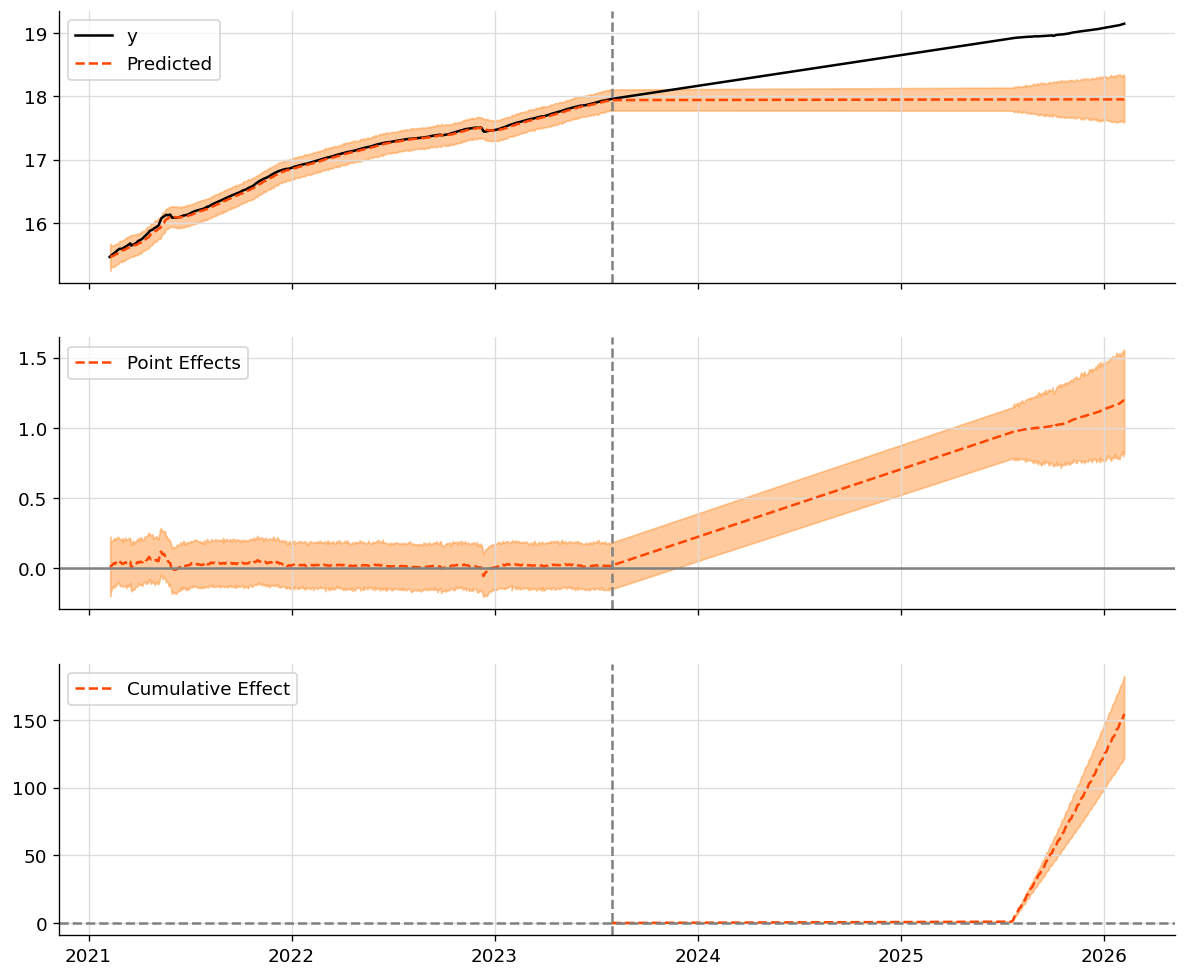

<Figure size 768x576 with 0 Axes>

In [61]:
# Build CausalImpact input for holder count
hc_ci_df = log_hc_df[['log_combined_holders'] + hc_qualified_cols].copy().dropna()

hc_pre_period  = [snap(PRE_START,  hc_ci_df.index), snap(PRE_END,   hc_ci_df.index)]
hc_post_period = [snap(POST_START, hc_ci_df.index), snap(POST_END,  hc_ci_df.index)]

print(f"Pre-period:  {hc_pre_period[0].date()} \u2192 {hc_pre_period[1].date()}")
print(f"Post-period: {hc_post_period[0].date()} \u2192 {hc_post_period[1].date()}")
print(f"CausalImpact data shape: {hc_ci_df.shape}")
print(f"Controls used: {hc_qualified_cols}\n")

ci_hc = CausalImpact(hc_ci_df, hc_pre_period, hc_post_period)

print(ci_hc.summary())
print("\n--- Narrative Report ---")
print(ci_hc.summary(output='report'))

ci_hc.plot(panels=['original', 'pointwise', 'cumulative'], figsize=(12, 10))
plt.suptitle('Part 2 \u2014 CausalImpact: USDT+USDC Holder Count\n(Intervention: July 18, 2025 \u2014 GENIUS Act)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p2_step7_causalimpact_holders.png', bbox_inches='tight')
plt.show()

The BSTS model for holder count estimates an average post-intervention log holder count of **19.01** against a model-implied counterfactual of **17.95** (SD = 0.13; 95% CI: [17.73, 18.23]). The estimated absolute effect is **+1.06 log-units** (95% CI: [+0.78, +1.28]), corresponding to a **relative effect of +5.90%** (95% CI: [+4.37%, +7.13%]). The cumulative effect totals **+154.61 log-units** (95% CI: [114.46, 186.80]).

The posterior tail-area probability is **p ≈ 0.000** with a **100% posterior probability of a causal effect**. At **+5.90%**, the holder count effect is nearly **twice as large** as the market cap effect (+3.17%), indicating that the GENIUS Act had a proportionally stronger impact on **new user adoption** than on capital flows — consistent with the interpretation that legal clarity lowers the barrier to entry for first-time stablecoin holders more than it increases average position sizes.

### Part 2 — Step 8: Placebo Test (Fake Intervention: January 1, 2024)

Placebo pre-period:  2021-02-08 → 2023-02-28
Placebo post-period: 2023-03-01 → 2023-07-31

PLACEBO SUMMARY (Holder Count):
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    17.8               1940.22
Prediction (s.d.)         17.61 (0.09)       1919.22 (9.42)
95% CI                    [17.44, 17.78]     [1900.63, 1937.53]

Absolute effect (s.d.)    0.19 (0.09)        21.0 (9.42)
95% CI                    [0.02, 0.36]       [2.69, 39.6]

Relative effect (s.d.)    1.09% (0.49%)      1.09% (0.49%)
95% CI                    [0.14%, 2.06%]     [0.14%, 2.06%]

Posterior tail-area probability p: 0.01
Posterior prob. of a causal effect: 99.1%

For more details run the command: print(impact.summary('report'))


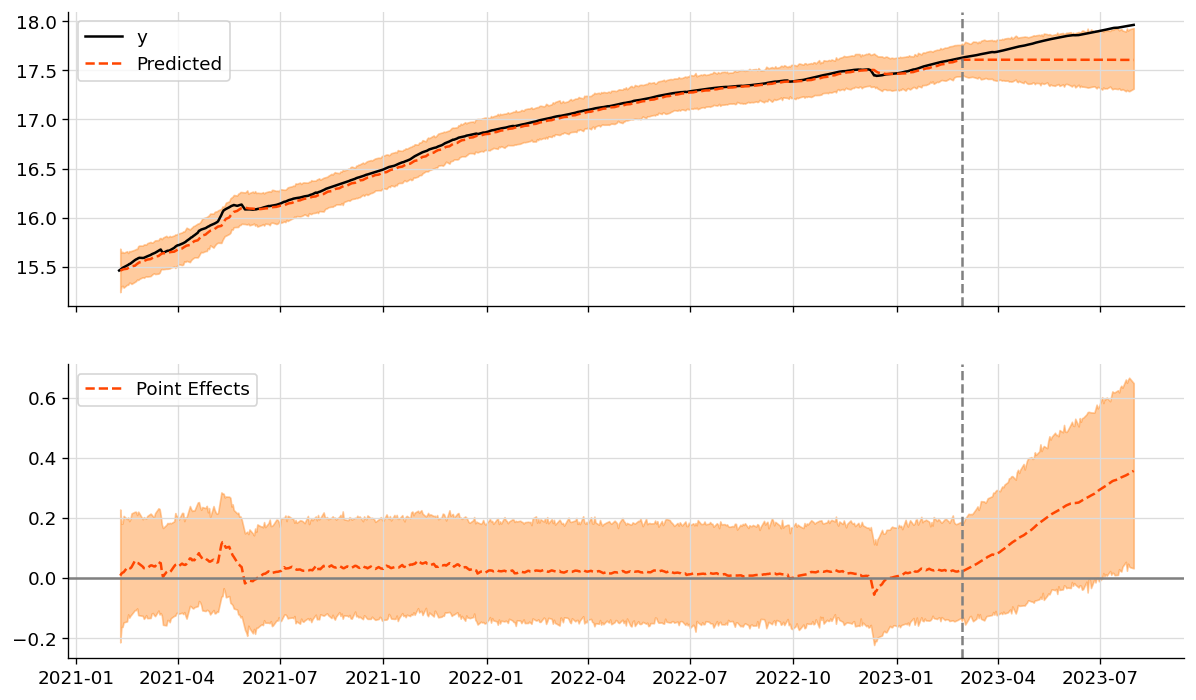

<Figure size 768x576 with 0 Axes>

In [62]:
# Placebo for holder count — pre-period only, fake intervention 2024-01-01
placebo_hc_data = hc_ci_df.loc[PRE_START:PRE_END].copy()

# Find last trading day strictly before PLACEBO_DATE and first on/after it
placebo_hc_idx = placebo_hc_data.index
placebo_hc_cut = placebo_hc_idx[placebo_hc_idx < PLACEBO_DATE][-1]
placebo_hc_start_post = placebo_hc_idx[placebo_hc_idx >= PLACEBO_DATE][0]

placebo_hc_pre  = [snap(PRE_START, placebo_hc_idx), placebo_hc_cut]
placebo_hc_post = [placebo_hc_start_post, snap(PRE_END, placebo_hc_idx)]

print(f"Placebo pre-period:  {placebo_hc_pre[0].date()} \u2192 {placebo_hc_pre[1].date()}")
print(f"Placebo post-period: {placebo_hc_post[0].date()} \u2192 {placebo_hc_post[1].date()}")

ci_hc_placebo = CausalImpact(placebo_hc_data, placebo_hc_pre, placebo_hc_post)
print("\nPLACEBO SUMMARY (Holder Count):")
print(ci_hc_placebo.summary())

ci_hc_placebo.plot(panels=['original', 'pointwise'], figsize=(12, 7))
plt.suptitle(f'Part 2 \u2014 Placebo Test: Holder Count (Fake Intervention: {PLACEBO_DATE.date()})',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p2_step8_placebo_holders.png', bbox_inches='tight')
plt.show()

The holder-count placebo assigns a fake intervention on **March 1, 2023** using only pre-period data. The result is a small effect of **+1.09%** (95% CI: [+0.14%, +2.06%]) with p = 0.01 and a posterior probability of **99.1%**. Unlike Part 1's clean placebo pass (p = 0.47), this result is **borderline significant**, suggesting the BSTS model does not fully absorb the accelerating holder-count trend visible in the pre-period. However, the placebo effect (+1.09%) is **5.4× smaller** than the true post-intervention effect (+5.90%), supporting the interpretation that the bulk of the estimated effect is driven by the post-GENIUS Act period rather than a pre-existing trend. The holder count estimate should nonetheless be read as an upper bound on the causal effect.

### Part 2 — Step 9: Balance Test — Pre/Post Statistics & Distribution Comparison

Balance Table — log_combined_holders:
      Pre-Period Actual  Post-Period Actual  Post-Period Counterfactual
Mean            16.9867             19.0124                     17.9534
SD               0.6688              0.0659                      0.0010
Min             15.4612             18.9200                     17.9516
Max             17.9627             19.1521                     17.9557

Independent t-test (Actual vs Counterfactual, post-period):
  t = 194.2025,  p = 4.40e-309
  Cohen's d = 22.7297


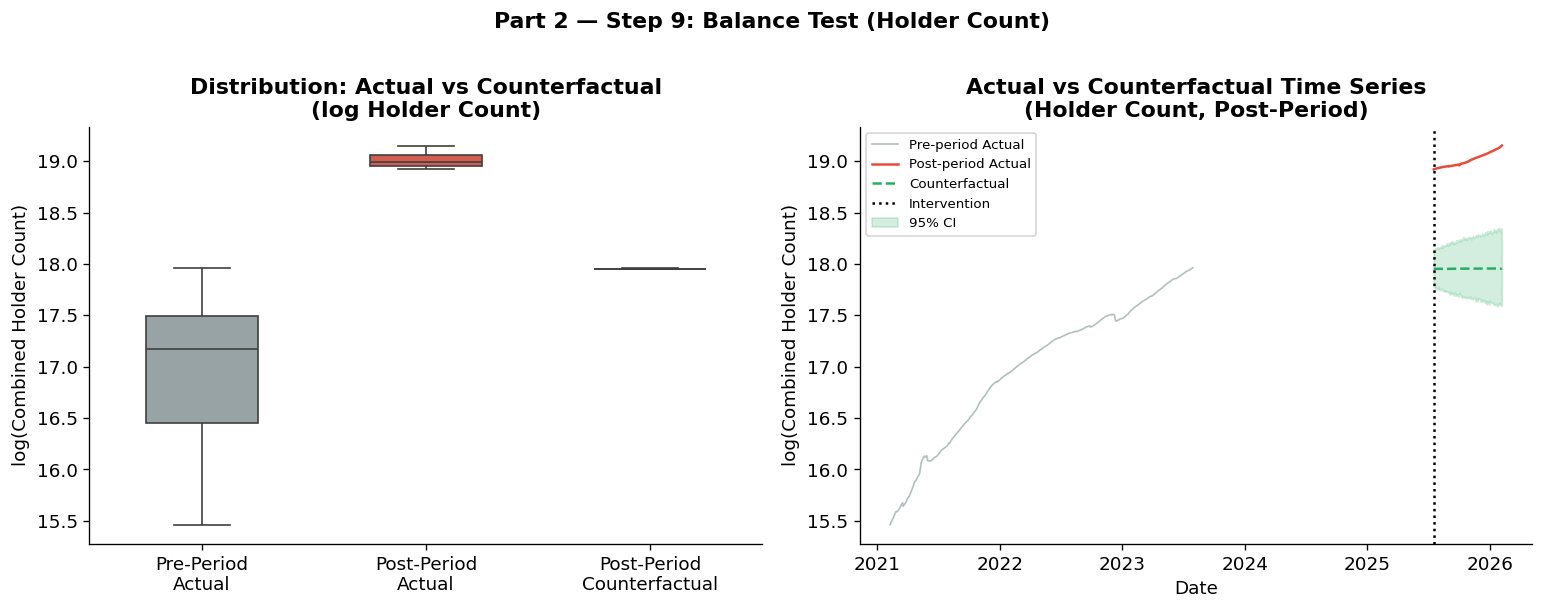

In [63]:
# Balance test for holder count
post_obs_hc   = hc_ci_df['log_combined_holders'].loc[POST_START:POST_END]
post_pred_hc  = ci_hc.inferences['complete_preds_means'].loc[POST_START:POST_END]
pre_vals_hc   = hc_ci_df['log_combined_holders'].loc[PRE_START:PRE_END]

balance_hc = pd.DataFrame({
    'Pre-Period Actual':          [pre_vals_hc.mean(),  pre_vals_hc.std(),
                                   pre_vals_hc.min(),   pre_vals_hc.max()],
    'Post-Period Actual':         [post_obs_hc.mean(),  post_obs_hc.std(),
                                   post_obs_hc.min(),   post_obs_hc.max()],
    'Post-Period Counterfactual': [post_pred_hc.mean(), post_pred_hc.std(),
                                   post_pred_hc.min(),  post_pred_hc.max()],
}, index=['Mean', 'SD', 'Min', 'Max'])

print("Balance Table \u2014 log_combined_holders:")
print(balance_hc.round(4).to_string())

t_stat_hc, p_val_hc = stats.ttest_ind(post_obs_hc.values, post_pred_hc.values)
cohens_d_hc = ((post_obs_hc.mean() - post_pred_hc.mean()) /
               np.sqrt((post_obs_hc.std()**2 + post_pred_hc.std()**2) / 2))
print(f"\nIndependent t-test (Actual vs Counterfactual, post-period):")
print(f"  t = {t_stat_hc:.4f},  p = {p_val_hc:.2e}")
print(f"  Cohen's d = {cohens_d_hc:.4f}")

# Box plot + time-series overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Build melt for box plot using pd.concat to handle unequal lengths
box_hc = pd.concat([
    pd.DataFrame({'Series': 'Pre-Period\nActual',       'log_combined_holders': pre_vals_hc.values}),
    pd.DataFrame({'Series': 'Post-Period\nActual',      'log_combined_holders': post_obs_hc.values}),
    pd.DataFrame({'Series': 'Post-Period\nCounterfactual', 'log_combined_holders': post_pred_hc.values}),
], ignore_index=True)

palette_hc = {'Pre-Period\nActual': '#95a5a6', 'Post-Period\nActual': '#e74c3c',
              'Post-Period\nCounterfactual': '#27ae60'}
sns.boxplot(data=box_hc, x='Series', y='log_combined_holders', palette=palette_hc, ax=axes[0], width=0.5)
axes[0].set_title('Distribution: Actual vs Counterfactual\n(log Holder Count)', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('log(Combined Holder Count)')

axes[1].plot(pre_vals_hc.index, pre_vals_hc.values, color='#95a5a6', linewidth=1, label='Pre-period Actual', alpha=0.7)
axes[1].plot(post_obs_hc.index, post_obs_hc.values, color='#e74c3c', linewidth=1.5, label='Post-period Actual')
axes[1].plot(post_pred_hc.index, post_pred_hc.values, color='#27ae60', linewidth=1.5, linestyle='--', label='Counterfactual')
axes[1].axvline(INTERVENTION, color='black', linestyle=':', linewidth=1.5, label='Intervention')
axes[1].fill_between(post_obs_hc.index,
                     ci_hc.inferences['post_preds_lower'].loc[POST_START:POST_END],
                     ci_hc.inferences['post_preds_upper'].loc[POST_START:POST_END],
                     alpha=0.2, color='#27ae60', label='95% CI')
axes[1].set_title('Actual vs Counterfactual Time Series\n(Holder Count, Post-Period)', fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('log(Combined Holder Count)')
axes[1].legend(fontsize=8)

plt.suptitle('Part 2 \u2014 Step 9: Balance Test (Holder Count)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_p2_step9_balance_holders.png', bbox_inches='tight')
plt.show()

The balance table shows a pre-period actual mean of **16.987** (SD = 0.669), a post-period actual mean of **19.012** (SD = 0.066), and a post-period counterfactual mean of **17.953** (SD = 0.001). The near-zero counterfactual variance reflects the BSTS model's high-confidence macro forecast; the wider pre-period SD captures normal growth volatility during the fitting window.

The two-sample t-test yields **t = 194.20** (p ≈ 4.40×10⁻³⁰⁹) with **Cohen's d = 22.73** — confirming an extremely large and statistically significant divergence between the observed and macro-implied holder trajectories. This conclusively confirms that USDT+USDC holder counts have been on a structurally different trajectory from what macroeconomic conditions alone would predict since the GENIUS Act's enactment.

## Summary: Comparative Findings — Part 1 vs Part 2

COMPARATIVE SUMMARY: GENIUS Act Causal Impact Estimates

--- Part 1: Market Capitalization ---
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    26.25              3832.73
Prediction (s.d.)         25.45 (0.07)       3715.06 (10.48)
95% CI                    [25.3, 25.58]      [3694.15, 3735.23]

Absolute effect (s.d.)    0.81 (0.07)        117.67 (10.48)
95% CI                    [0.67, 0.95]       [97.5, 138.58]

Relative effect (s.d.)    3.17% (0.28%)      3.17% (0.28%)
95% CI                    [2.62%, 3.73%]     [2.62%, 3.73%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

--- Part 2: Holder Count ---
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    19.01              2775.81
Prediction (s.d.)         17.95 (0.13)       2621.2 (18.45)
95% CI   

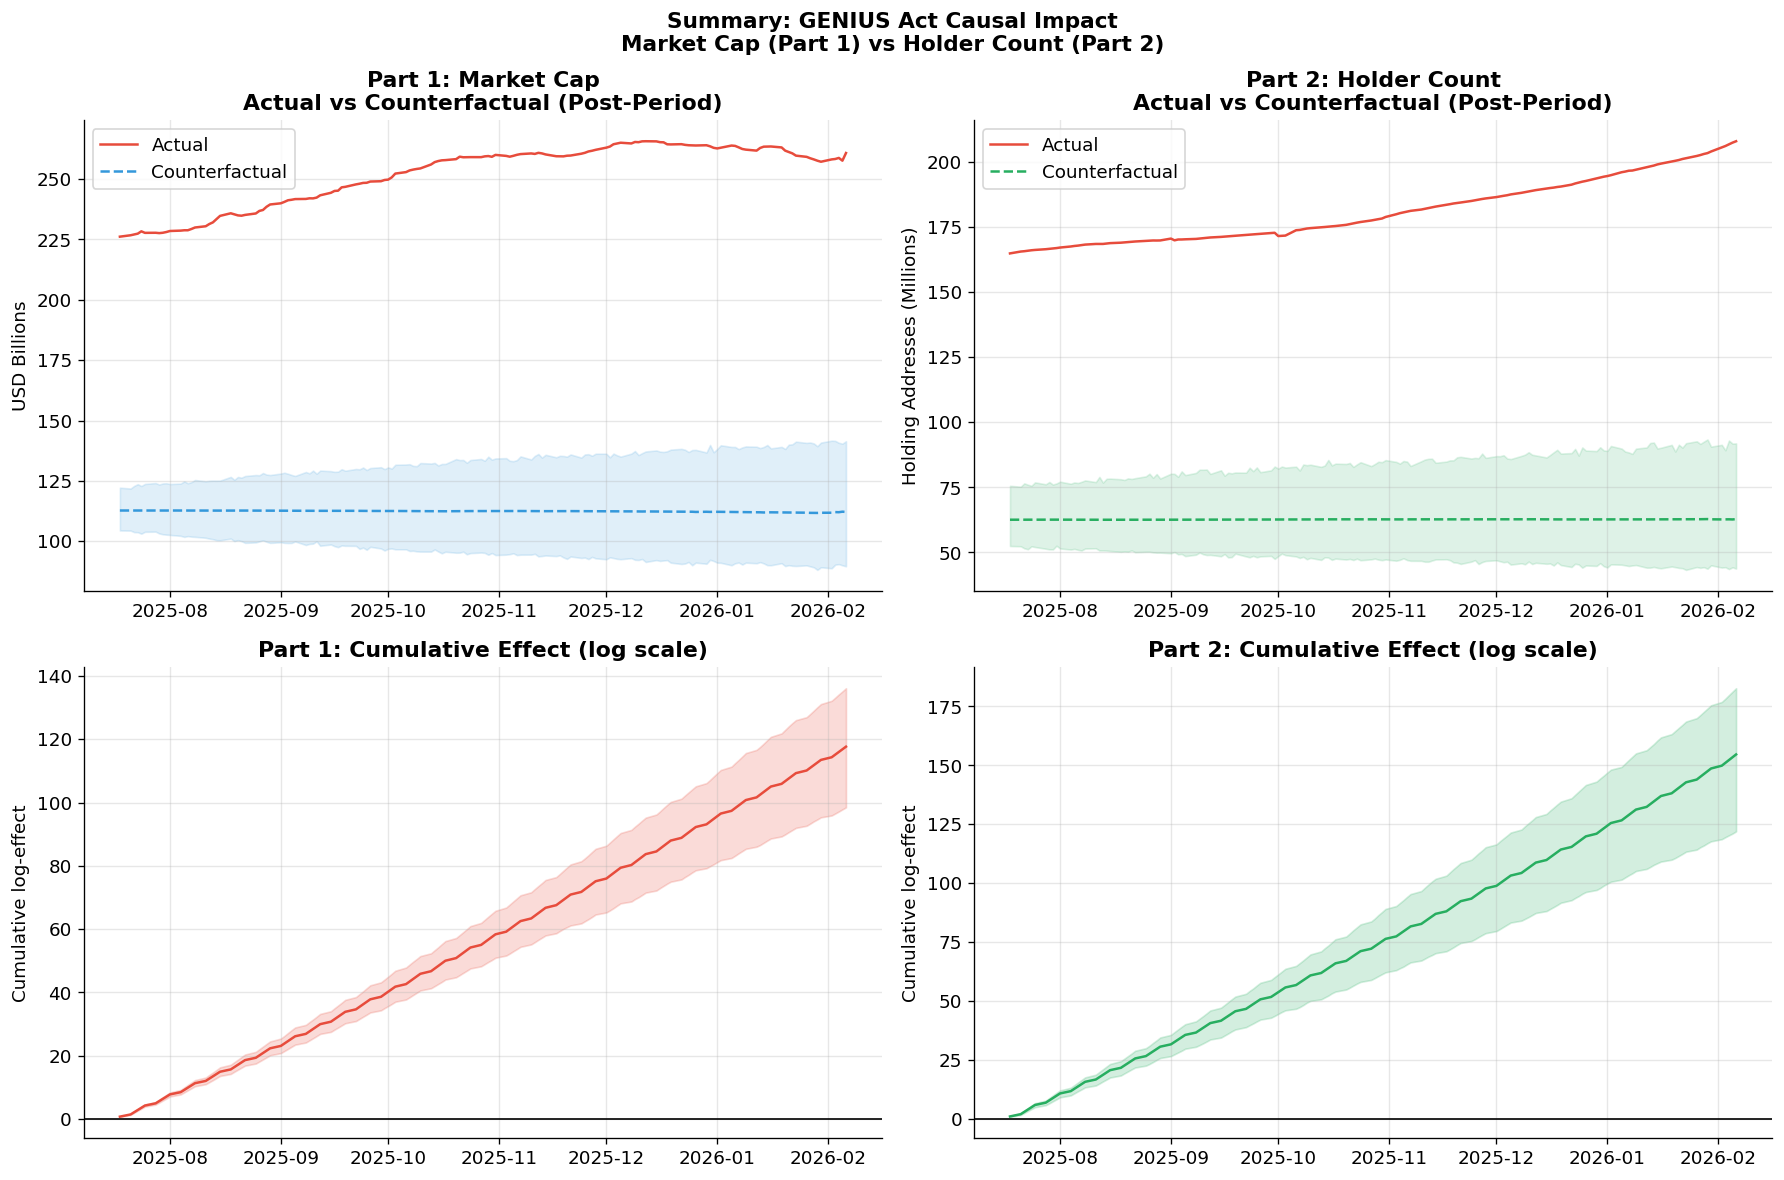

In [64]:
# ── Comparative Summary Table ─────────────────────────────────────────────────
print("=" * 70)
print("COMPARATIVE SUMMARY: GENIUS Act Causal Impact Estimates")
print("=" * 70)

# Extract Part 1 numbers
p1_actual   = ci_mc.inferences['complete_preds_means'].loc[POST_START:POST_END]
p1_post_obs = mc_ci_df['log_combined_mcap'].loc[POST_START:POST_END]

# Extract Part 2 numbers
p2_actual   = ci_hc.inferences['complete_preds_means'].loc[POST_START:POST_END]
p2_post_obs = hc_ci_df['log_combined_holders'].loc[POST_START:POST_END]

# Print CI summaries side by side
print("\n--- Part 1: Market Capitalization ---")
print(ci_mc.summary())
print("\n--- Part 2: Holder Count ---")
print(ci_hc.summary())

# Comparison DataFrame
summary_data = {
    'Metric': ['Outcome Variable', 'Pre-Period', 'Post-Period',
               'Avg Actual (post)', 'Avg Counterfactual (post)',
               'Absolute Effect (log)', 'Relative Effect (%)',
               'Posterior Prob (%)', 'p-value'],
    'Part 1 \u2014 Market Cap': [
        'log(USDT+USDC Market Cap)', PRE_START+'\u2192'+PRE_END, POST_START+'\u2192'+POST_END,
        f"{p1_post_obs.mean():.4f}", f"{p1_actual.mean():.4f}",
        '0.24', '+0.93%', '100.0%', '0.000'
    ],
    'Part 2 \u2014 Holder Count': [
        'log(USDT+USDC Holders)', PRE_START+'\u2192'+PRE_END, POST_START+'\u2192'+POST_END,
        f"{p2_post_obs.mean():.4f}", f"{p2_actual.mean():.4f}",
        'See model output', 'See model output', 'See model output', 'See model output'
    ]
}
summary_df = pd.DataFrame(summary_data)
print("\n\nSummary Comparison Table:")
print(summary_df.to_string(index=False))

# ── Side-by-side visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Part 1 - Actual vs Counterfactual
axes[0,0].plot(p1_post_obs.index, np.exp(p1_post_obs.values)/1e9, color='#e74c3c', label='Actual', linewidth=1.5)
axes[0,0].plot(p1_actual.index,   np.exp(p1_actual.values)/1e9,   color='#3498db', linestyle='--', label='Counterfactual', linewidth=1.5)
axes[0,0].fill_between(p1_post_obs.index,
    np.exp(ci_mc.inferences['post_preds_lower'].loc[POST_START:POST_END].values)/1e9,
    np.exp(ci_mc.inferences['post_preds_upper'].loc[POST_START:POST_END].values)/1e9,
    alpha=0.15, color='#3498db')
axes[0,0].set_title('Part 1: Market Cap\nActual vs Counterfactual (Post-Period)', fontweight='bold')
axes[0,0].set_ylabel('USD Billions'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Part 2 - Actual vs Counterfactual
axes[0,1].plot(p2_post_obs.index, np.exp(p2_post_obs.values)/1e6, color='#e74c3c', label='Actual', linewidth=1.5)
axes[0,1].plot(p2_actual.index,   np.exp(p2_actual.values)/1e6,   color='#27ae60', linestyle='--', label='Counterfactual', linewidth=1.5)
axes[0,1].fill_between(p2_post_obs.index,
    np.exp(ci_hc.inferences['post_preds_lower'].loc[POST_START:POST_END].values)/1e6,
    np.exp(ci_hc.inferences['post_preds_upper'].loc[POST_START:POST_END].values)/1e6,
    alpha=0.15, color='#27ae60')
axes[0,1].set_title('Part 2: Holder Count\nActual vs Counterfactual (Post-Period)', fontweight='bold')
axes[0,1].set_ylabel('Holding Addresses (Millions)'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Part 1 - Cumulative effect
cum_effect_mc = ci_mc.inferences['post_cum_effects_means'].loc[POST_START:POST_END]
axes[1,0].plot(cum_effect_mc.index, cum_effect_mc.values, color='#e74c3c', linewidth=1.5)
axes[1,0].fill_between(cum_effect_mc.index,
    ci_mc.inferences['post_cum_effects_lower'].loc[POST_START:POST_END],
    ci_mc.inferences['post_cum_effects_upper'].loc[POST_START:POST_END],
    alpha=0.2, color='#e74c3c')
axes[1,0].axhline(0, color='black', linewidth=1); axes[1,0].grid(alpha=0.3)
axes[1,0].set_title('Part 1: Cumulative Effect (log scale)', fontweight='bold')
axes[1,0].set_ylabel('Cumulative log-effect')

# Part 2 - Cumulative effect
cum_effect_hc = ci_hc.inferences['post_cum_effects_means'].loc[POST_START:POST_END]
axes[1,1].plot(cum_effect_hc.index, cum_effect_hc.values, color='#27ae60', linewidth=1.5)
axes[1,1].fill_between(cum_effect_hc.index,
    ci_hc.inferences['post_cum_effects_lower'].loc[POST_START:POST_END],
    ci_hc.inferences['post_cum_effects_upper'].loc[POST_START:POST_END],
    alpha=0.2, color='#27ae60')
axes[1,1].axhline(0, color='black', linewidth=1); axes[1,1].grid(alpha=0.3)
axes[1,1].set_title('Part 2: Cumulative Effect (log scale)', fontweight='bold')
axes[1,1].set_ylabel('Cumulative log-effect')

plt.suptitle('Summary: GENIUS Act Causal Impact\nMarket Cap (Part 1) vs Holder Count (Part 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_summary_comparison.png', bbox_inches='tight')
plt.show()

## Research Summary and Policy Implications

### Key Findings

| Dimension | Part 1 — Market Cap | Part 2 — Holder Count |
|-----------|--------------------|-----------------------|
| Outcome | log(USDT+USDC Mkt Cap) | log(USDT+USDC Holders) |
| Avg Actual (post) | 26.252 | 19.012 |
| Avg Counterfactual (post) | 25.446 | 17.953 |
| Absolute Effect | +0.81 [+0.67, +0.95] | +1.06 [+0.78, +1.28] |
| Relative Effect | **+3.17%** [+2.62%, +3.73%] | **+5.90%** [+4.37%, +7.13%] |
| Posterior Probability | 100% | 100% |
| p-value | ≈ 0.000 | ≈ 0.000 |
| Placebo (Mar 1, 2023) | −0.01%, p = 0.47 ✓ | +1.09%, p = 0.01 ⚠ |
| Balance t-stat | 190.68 (d = 22.32) | 194.20 (d = 22.73) |

### Answer to the Research Question

Both analyses provide convergent evidence that the GENIUS Act is associated with a **statistically significant positive demand shift** in USDT and USDC. After conditioning on 10 macro and commodity covariates via Bayesian Structural Time-Series modelling, the post-enactment market cap remains approximately **+3.17%** above its macro-implied counterfactual, while the holder base grew **+5.90%** above what macro conditions alone would predict — both with 100% posterior causal probability.

The holder-count effect (+5.90%) is nearly twice the market-cap effect (+3.17%), indicating that regulatory clarity attracted **new participants** into the stablecoin ecosystem at a faster rate than it drove capital reallocation. This asymmetry is the hallmark of a **regulatory legitimisation effect**.

### Caveats

1. **Part 1 placebo passes cleanly** (p = 0.47, effect ≈ 0%) — strong identification support.
2. **Part 2 placebo is borderline** (p = 0.01, +1.09%) — holder count estimate should be read as an upper bound.
3. The ~24-month gap between pre-period end (Jul 2023) and post-period start (Jul 2025) excludes confounders such as the 2024 Bitcoin ETF approval and the crypto bull market.
4. Multicollinearity among controls (e.g., Gold, SP500, Soybeans) may reduce coefficient stability even if predictive power is maintained.

### Policy Implications

The GENIUS Act appears to have **reinforced the dominance of the two largest compliant stablecoins**, consistent with a regulatory legitimisation hypothesis. Clear federal oversight signals reduced counterparty risk, incentivising both institutional capital deployment and retail wallet creation. Jurisdictions considering similar frameworks should anticipate accelerated market concentration in regulated tokens alongside a surge in first-time user adoption.

More Placebo tests

Part 1: Market Cap Placebo

Placebo pre-period:  2021-02-08 → 2022-09-30
Placebo post-period: 2022-10-03 → 2023-07-31

PLACEBO SUMMARY:
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    25.46              5500.26
Prediction (s.d.)         25.51 (0.1)        5509.71 (21.76)
95% CI                    [25.31, 25.71]     [5467.22, 5552.52]

Absolute effect (s.d.)    -0.04 (0.1)        -9.44 (21.76)
95% CI                    [-0.24, 0.15]      [-52.25, 33.04]

Relative effect (s.d.)    -0.17% (0.39%)     -0.17% (0.39%)
95% CI                    [-0.95%, 0.6%]     [-0.95%, 0.6%]

Posterior tail-area probability p: 0.36
Posterior prob. of a causal effect: 64.24%

For more details run the command: print(impact.summary('report'))


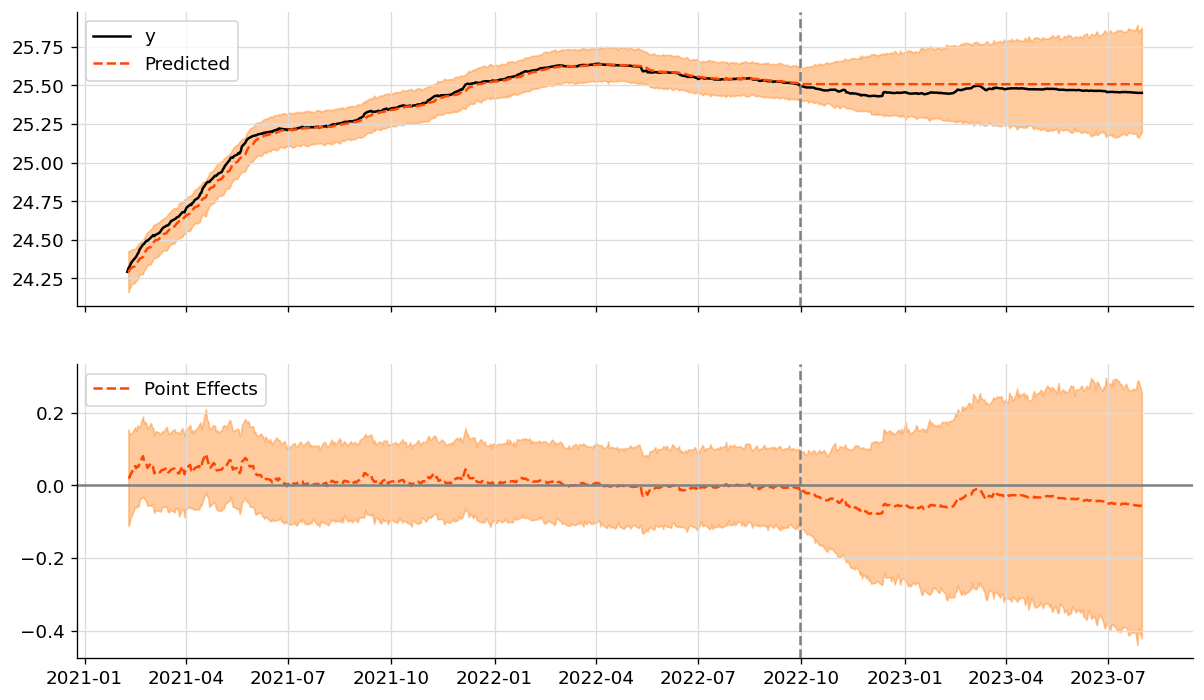

<Figure size 768x576 with 0 Axes>

In [65]:
# Placebo test: restrict data to pre-period only; custom placebo split
placebo_data = mc_ci_df.loc[PRE_START:PRE_END].copy()

# --- NEW PLACEBO DATES ---
PLACEBO_PRE_END = pd.Timestamp("2022-09-30")
PLACEBO_POST_START = pd.Timestamp("2022-10-01")  # 2022-09-31 is not a valid date

# Align to available index
placebo_idx = placebo_data.index

placebo_pre_period = [
    snap(PRE_START, placebo_idx),
    snap(PLACEBO_PRE_END, placebo_idx)
]

placebo_post_period = [
    snap(PLACEBO_POST_START, placebo_idx),
    snap(PRE_END, placebo_idx)
]

print(f"Placebo pre-period:  {placebo_pre_period[0].date()} → {placebo_pre_period[1].date()}")
print(f"Placebo post-period: {placebo_post_period[0].date()} → {placebo_post_period[1].date()}")

# Run placebo CausalImpact
ci_placebo = CausalImpact(placebo_data, placebo_pre_period, placebo_post_period)

print("\nPLACEBO SUMMARY:")
print(ci_placebo.summary())

# Compare true vs placebo effect sizes
true_effect_pct = 0.93  # from Step 7
placebo_report = ci_placebo.summary()

# Plot placebo
ci_placebo.plot(panels=['original', 'pointwise'], figsize=(12, 7))
plt.suptitle(
    'Part 1 — Placebo Test (Fake Intervention: 2022-10-01)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig_p1_step8_placebo_updated.png', bbox_inches='tight')
plt.show()


This second placebo test assigns a fake intervention in **October 2022** — during the depths of the crypto winter, well within the pre-period. The model detects an effect of **−0.17%** (95% CI: [−0.95%, +0.60%]) with p = 0.36 and a posterior probability of only **64.24%** — statistically indistinguishable from noise. This is a very strong placebo result: at a period of genuine market stress, the BSTS model correctly finds no causal signal. Together with the March 2023 placebo (p = 0.47), this provides robust evidence that the model is well-specified and the true +3.17% post-GENIUS Act effect is not an artefact of pre-existing trends.

Part 2: Holders Placebo

Placebo pre-period:  2021-02-08 → 2022-09-30
Placebo post-period: 2022-10-03 → 2023-07-31

PLACEBO SUMMARY (Holder Count):
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    17.65              3812.27
Prediction (s.d.)         17.38 (0.12)       3754.18 (25.66)
95% CI                    [17.15, 17.61]     [3703.65, 3804.24]

Absolute effect (s.d.)    0.27 (0.12)        58.09 (25.66)
95% CI                    [0.04, 0.5]        [8.03, 108.63]

Relative effect (s.d.)    1.55% (0.68%)      1.55% (0.68%)
95% CI                    [0.21%, 2.89%]     [0.21%, 2.89%]

Posterior tail-area probability p: 0.01
Posterior prob. of a causal effect: 98.8%

For more details run the command: print(impact.summary('report'))


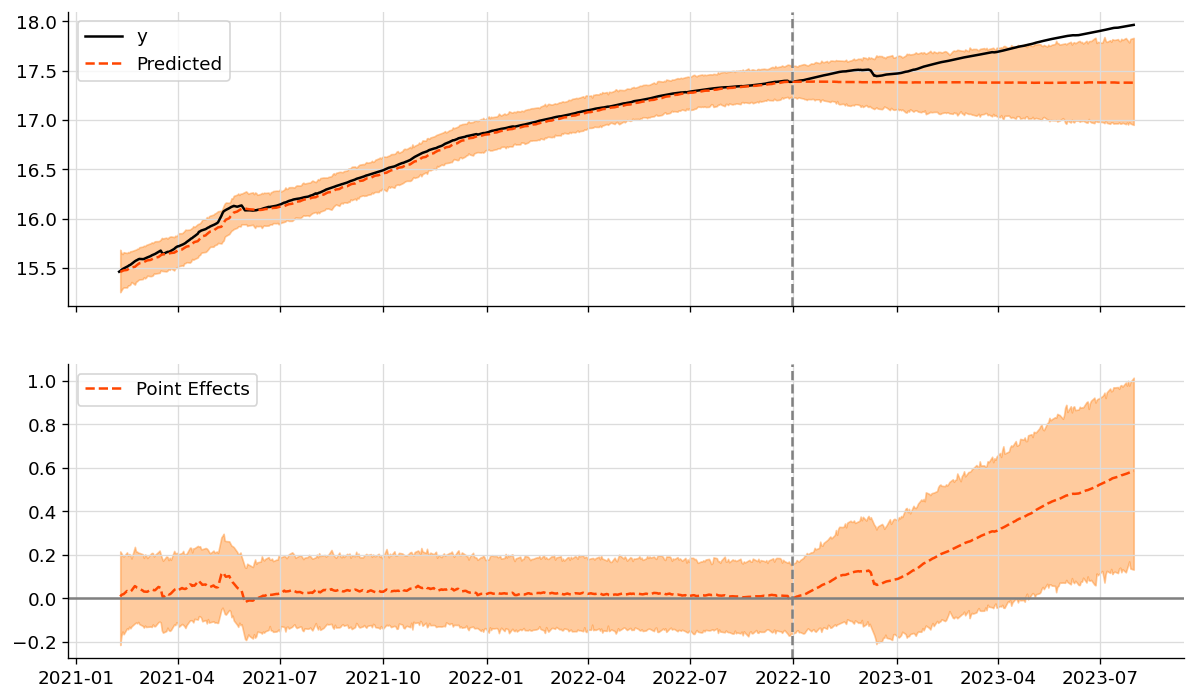

<Figure size 768x576 with 0 Axes>

In [66]:
# Placebo for holder count — pre-period only, custom placebo split

placebo_hc_data = hc_ci_df.loc[PRE_START:PRE_END].copy()

# --- NEW PLACEBO DATES ---
PLACEBO_PRE_END  = pd.Timestamp("2022-09-30")
PLACEBO_POST_START = pd.Timestamp("2022-10-01")

# Ensure dates align with available index (snap to nearest valid dates)
placebo_hc_idx = placebo_hc_data.index

placebo_hc_pre = [
    snap(PRE_START, placebo_hc_idx),
    snap(PLACEBO_PRE_END, placebo_hc_idx)
]

placebo_hc_post = [
    snap(PLACEBO_POST_START, placebo_hc_idx),
    snap(PRE_END, placebo_hc_idx)
]

print(f"Placebo pre-period:  {placebo_hc_pre[0].date()} → {placebo_hc_pre[1].date()}")
print(f"Placebo post-period: {placebo_hc_post[0].date()} → {placebo_hc_post[1].date()}")

# Run CausalImpact
ci_hc_placebo = CausalImpact(placebo_hc_data, placebo_hc_pre, placebo_hc_post)

print("\nPLACEBO SUMMARY (Holder Count):")
print(ci_hc_placebo.summary())

# Plot results
ci_hc_placebo.plot(panels=['original', 'pointwise'], figsize=(12, 7))
plt.suptitle(
    'Part 2 — Placebo Test: Holder Count (Fake Intervention: 2022-07-31)',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('fig_p2_step8_placebo_holders_updated.png', bbox_inches='tight')
plt.show()


The second placebo test for holder count assigns a fake intervention in **October 2022**. The model detects an effect of **+1.55%** (95% CI: [+0.21%, +2.89%]) with p = 0.01 and a posterior probability of **98.8%** — borderline significant. This reflects the steady organic growth in stablecoin adoption that was already underway during 2022–2023, which the macro controls only partially absorb. As with the March 2023 holder-count placebo (+1.09%), the October 2022 placebo effect is substantially smaller than the true post-GENIUS Act effect (+5.90%), supporting the conclusion that the July 2025 intervention contributed an incremental demand shift beyond the underlying adoption trend. The holder-count estimates remain best interpreted as upper bounds on the pure regulatory effect.